# Four Qubit Chip Design

In [1]:
%reload_ext autoreload
%autoreload 2

## Prerequisite

In [2]:
import os
from collections import OrderedDict

import numpy as np
import pandas as pd
from IPython.display import Image, display
from qiskit_metal import Dict, MetalGUI, designs
from qiskit_metal.qlibrary.qubits.transmon_pocket_cl import TransmonPocketCL
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.launchpad_wb_coupled import (
    LaunchpadWirebondCoupled,
)
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander

## Four Qubit Design

We will aim for the following parameters on our chip;

- qubit frequency => 4.8, 5, 5.2, 5.4 GHz
- qubit anharmonicity => 300 MHz
- qubit-bus coupling ($g_{q - bus}$) => 80 MHz
- qubit-readout ($\chi_{qc}$ ) => 1 MHz
- bus frequency 
    - Q1 (bus_12, bus_14) => 5.8, 6.0 GHz
    - Q2 (bus_23, bus_12) => 6.2, 5.8 GHz
    - Q3 (bus_34, bus_23) => 6.4, 6.2 GHz
    - Q4 (bus_14, bus_34) => 6.0, 6.4 GHz
- readout frequencies => 6.8, 7, 7.2, 7.4 GHz
- readout Q_external => 2000 ????

In [3]:
design = designs.DesignPlanar()

gui = MetalGUI(design)

In [4]:
design.overwrite_enabled = True

In [5]:
design.variables["cpw_width"] = "10 um"
design.variables["cpw_gap"] = "6 um"
design._chips["main"]["size"]["size_x"] = "9mm"
design._chips["main"]["size"]["size_y"] = "6.5mm"

We need 4 transmons with 3 connection pads each and a chargeline. Let's explore the options of one transmon

In [6]:
TransmonPocketCL.get_template_options(design)

{'pos_x': '0.0um',
 'pos_y': '0.0um',
 'orientation': '0.0',
 'chip': 'main',
 'layer': '1',
 'connection_pads': {},
 '_default_connection_pads': {'pad_gap': '15um',
  'pad_width': '125um',
  'pad_height': '30um',
  'pad_cpw_shift': '5um',
  'pad_cpw_extent': '25um',
  'cpw_width': 'cpw_width',
  'cpw_gap': 'cpw_gap',
  'cpw_extend': '100um',
  'pocket_extent': '5um',
  'pocket_rise': '65um',
  'loc_W': '+1',
  'loc_H': '+1'},
 'pad_gap': '30um',
 'inductor_width': '20um',
 'pad_width': '455um',
 'pad_height': '90um',
 'pocket_width': '650um',
 'pocket_height': '650um',
 'make_CL': True,
 'cl_gap': '6um',
 'cl_width': '10um',
 'cl_length': '20um',
 'cl_ground_gap': '6um',
 'cl_pocket_edge': '0',
 'cl_off_center': '50um',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False,
 'hfss_inductance': '10nH',
 'hfss_capacitance': 0,
 'hfss_resistance': 0,
 'hfss_mesh_kw_jj': 7e-06,
 'q3d_inductance': '10nH',
 'q3d_capacitance': 0,
 

We want to change the `pad_width` for these transmons, as well as define the 3 connection pads and chargeline.

To apply the same modifications to all 4 transmons, we define a single option-dictionary to pass to all transmons at the monent of creation

In [7]:
offset_tm = 69  # we the transmon slightly out of center-line

q1 = TransmonPocketCL(
    design,
    "Q1",
    options=dict(
        pos_x="-2420um",
        pos_y=f"{offset_tm}um",
        orientation="180",
        gds_cell_name="FakeJunction_01",
        cl_off_center="-50um",
        cl_pocket_edge="180",
        connection_pads=dict(
            readout=dict(loc_W=+1, loc_H=-1, pad_width="70um", cpw_extend="50um"),
            bus_12=dict(loc_W=-1, loc_H=-1, pad_width="125um", cpw_extend="50um"),
            bus_14=dict(loc_W=-1, loc_H=+1, pad_width="110um", cpw_extend="50um"),
        ),
    ),
)
q2 = TransmonPocketCL(
    design,
    "Q2",
    options=dict(
        pos_x="0um",
        pos_y="+857.6um",
        orientation="90",
        gds_cell_name="FakeJunction_01",
        cl_off_center="-50um",
        cl_pocket_edge="180",
        connection_pads=dict(
            readout=dict(loc_W=+1, loc_H=-1, pad_width="70um", cpw_extend="50um"),
            bus_23=dict(loc_W=-1, loc_H=-1, pad_width="125um", cpw_extend="50um"),
            bus_12=dict(loc_W=-1, loc_H=+1, pad_width="110um", cpw_extend="50um"),
        ),
    ),
)

q3 = TransmonPocketCL(
    design,
    "Q3",
    options=dict(
        pos_x="+2420um",
        pos_y=f"{offset_tm}um",
        gds_cell_name="FakeJunction_01",
        cl_off_center="-50um",
        cl_pocket_edge="180",
        connection_pads=dict(
            readout=dict(loc_W=+1, loc_H=-1, pad_width="70um", cpw_extend="50um"),
            bus_34=dict(loc_W=-1, loc_H=-1, pad_width="125um", cpw_extend="50um"),
            bus_23=dict(loc_W=-1, loc_H=+1, pad_width="110um", cpw_extend="50um"),
        ),
    ),
)

q4 = TransmonPocketCL(
    design,
    "Q4",
    options=dict(
        pos_x="0um",
        pos_y="-857.6um",
        orientation="270",
        gds_cell_name="FakeJunction_01",
        cl_off_center="-50um",
        cl_pocket_edge="180",
        connection_pads=dict(
            readout=dict(loc_W=+1, loc_H=-1, pad_width="70um", cpw_extend="50um"),
            bus_14=dict(loc_W=-1, loc_H=-1, pad_width="125um", cpw_extend="50um"),
            bus_34=dict(loc_W=-1, loc_H=+1, pad_width="110um", cpw_extend="50um"),
        ),
    ),
)

gui.rebuild()
gui.autoscale()

We can now create the 4 transmons by specifying the desired coordinates and orientations.

Let's now connect the transmons with tranismission lines. We want to have an "exact length" transmission line, so we will use the `RouteMeander`. Let's first observe what are the default options

In [8]:
RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

We want to globally override the default lead (straight initial segment leaving the transmon) and the default fillet (corner rounding radius). Let's collect this information in one dictionary

In [9]:
from qiskit_metal.analyses.em.cpw_calculations import guided_wavelength


def find_resonator_length(frequency, line_width, line_gap, N):
    # frequency in GHz
    # line_width/line_gap in um
    # N -> 2 for lambda/2, 4 for lambda/4
    # substrate dimensions and properties already set

    [lambdaG, etfSqrt, q] = guided_wavelength(
        frequency * 10**9,
        line_width * 10**-6,
        line_gap * 10**-6,
        750 * 10**-6,
        200 * 10**-9,
        11.9,
    )
    return str(lambdaG / N * 10**3) + " mm"

In [10]:
q1.pins.keys()

dict_keys(['readout', 'bus_12', 'bus_14', 'Charge_Line'])

In [11]:
bus_12 = find_resonator_length(frequency=5.8, line_width=10, line_gap=6, N=2)
bus_14 = find_resonator_length(frequency=6.0, line_width=10, line_gap=6, N=2)
bus_23 = find_resonator_length(frequency=6.2, line_width=10, line_gap=6, N=2)
bus_34 = find_resonator_length(frequency=6.4, line_width=10, line_gap=6, N=2)

bus_12 = str(round(float(bus_12.split()[0]), 2)) + "mm"
bus_14 = str(round(float(bus_14.split()[0]), 2)) + "mm"
bus_23 = str(round(float(bus_23.split()[0]), 2)) + "mm"
bus_34 = str(round(float(bus_34.split()[0]), 2)) + "mm"

print("bus_12 length: " + bus_12)
print("bus_14 length: " + bus_14)
print("bus_23 length: " + bus_23)
print("bus_34 length: " + bus_34)

bus_12 length: 10.31mm
bus_14 length: 9.97mm
bus_23 length: 9.64mm
bus_34 length: 9.34mm


In [12]:
fillet = "99.99um"
cpw_options = Dict(
    lead=Dict(start_straight="100um", end_straight="250um"), fillet=fillet
)

We then want each transmission line to be connected to different pins and to have different lengths and asymmetry w.r.t their centerline. Let's collect this information in other dictionaries. Before doing that, to manage the dictionaries in a simpler way, we redefine the `RouteMeander` signature by wrapping it into a convenience method named `connect`

In [13]:
def connect(
    cpw_name: str,
    pin1_comp_name: str,
    pin1_comp_pin: str,
    pin2_comp_name: str,
    pin2_comp_pin: str,
    length: str,
    asymmetry="0 um",
):
    """Connect two pins with a CPW."""
    myoptions = Dict(
        pin_inputs=Dict(
            start_pin=Dict(component=pin1_comp_name, pin=pin1_comp_pin),
            end_pin=Dict(component=pin2_comp_name, pin=pin2_comp_pin),
        ),
        total_length=length,
    )
    myoptions.update(cpw_options)
    myoptions.meander.asymmetry = asymmetry
    return RouteMeander(design, cpw_name, myoptions)

We can now proceed and define the meanders following the signature: `connect(cpw_name, pin1_comp_name, pin1_comp_pin, pin2_comp_name, pin2_comp_pin, length, asymmetry)`

In [14]:
asym = 500
cpw1 = connect(
    "cpw1", "Q1", "bus_12", "Q2", "bus_12", bus_12, f"+{asym + 0.75 * offset_tm}um"
)
cpw2 = connect(
    "cpw2", "Q3", "bus_23", "Q2", "bus_23", bus_23, f"-{asym + 0.75 * offset_tm}um"
)
cpw3 = connect(
    "cpw3", "Q3", "bus_34", "Q4", "bus_34", bus_34, f"+{asym - 1.25 * offset_tm}um"
)
cpw4 = connect(
    "cpw4", "Q1", "bus_14", "Q4", "bus_14", bus_14, f"-{asym - 1.25 * offset_tm}um"
)

gui.rebuild()
gui.autoscale()

### Let's now connect the core elements to the launchpads

First we setup the launchpad location and orientation

In [15]:
# V1 - Corners
launch_cl_q1 = LaunchpadWirebond(
    design,
    "Launch_CL_Q1",
    options=dict(pos_x="-3545um", pos_y="-2812um", orientation="90", lead_length="0um"),
)
launch_cl_q2 = LaunchpadWirebond(
    design,
    "Launch_CL_Q2",
    options=dict(pos_x="-3545um", pos_y="2812um", orientation="270", lead_length="0um"),
)
launch_cl_q3 = LaunchpadWirebond(
    design,
    "Launch_CL_Q3",
    options=dict(pos_x="3545um", pos_y="2812um", orientation="270", lead_length="0um"),
)
launch_cl_q4 = LaunchpadWirebond(
    design,
    "Launch_CL_Q4",
    options=dict(pos_x="3545um", pos_y="-2812um", orientation="90", lead_length="0um"),
)

# V2
launch_ro_q1 = LaunchpadWirebondCoupled(
    design,
    "Launch_RO_Q1",
    options=dict(pos_x="-4020um", pos_y="0", orientation="0", lead_length="30um"),
)
launch_ro_q2 = LaunchpadWirebondCoupled(
    design,
    "Launch_RO_Q2",
    options=dict(pos_x="990um", pos_y="2812um", orientation="270", lead_length="30um"),
)
launch_ro_q3 = LaunchpadWirebondCoupled(
    design,
    "Launch_RO_Q3",
    options=dict(pos_x="4020um", pos_y="0", orientation="180", lead_length="30um"),
)
launch_ro_q4 = LaunchpadWirebondCoupled(
    design,
    "Launch_RO_Q4",
    options=dict(pos_x="-990um", pos_y="-2812um", orientation="90", lead_length="30um"),
)

gui.rebuild()
gui.autoscale()

Then we route. First the V2 launchpads - Exchange Coupler Lines to Edges

Connected to the readout resonators of each qubit

Used for dispersive readout — you send a probe tone and measure the reflected/transmitted signal to determine the qubit state without directly measuring it

In [16]:
readout1 = find_resonator_length(frequency=6.8, line_width=10, line_gap=6, N=2)
readout2 = find_resonator_length(frequency=7.0, line_width=10, line_gap=6, N=2)
readout3 = find_resonator_length(frequency=7.2, line_width=10, line_gap=6, N=2)
readout4 = find_resonator_length(frequency=7.4, line_width=10, line_gap=6, N=2)

readout1 = str(round(float(readout1.split()[0]), 2)) + "mm"
readout2 = str(round(float(readout2.split()[0]), 2)) + "mm"
readout3 = str(round(float(readout3.split()[0]), 2)) + "mm"
readout4 = str(round(float(readout4.split()[0]), 2)) + "mm"

print("readout1 length: " + readout1)
print("readout2 length: " + readout2)
print("readout3 length: " + readout3)
print("readout4 length: " + readout4)

readout1 length: 8.79mm
readout2 length: 8.54mm
readout3 length: 8.31mm
readout4 length: 8.08mm


In [17]:
asym = 150
cpw_options = Dict(lead=Dict(start_straight="430um", end_straight="0um"), fillet=fillet)
readout1 = connect(
    "Readout1", "Q1", "readout", "Launch_RO_Q1", "tie", readout1, f"+{asym}um"
)
readout3 = connect(
    "Readout3", "Q3", "readout", "Launch_RO_Q3", "tie", readout3, f"+{asym}um"
)

asym = 200
cpw_options = Dict(lead=Dict(start_straight="535um", end_straight="0um"), fillet=fillet)
readout2 = connect(
    "Readout2", "Q2", "readout", "Launch_RO_Q2", "tie", readout2, f"+{asym}um"
)
readout4 = connect(
    "Readout4", "Q4", "readout", "Launch_RO_Q4", "tie", readout4, f"+{asym}um"
)

gui.rebuild()
gui.autoscale()

Finally we route the V1 launchpads - Charge Lines to Corners

We create the transmission lines between the corner launchpads and the open to grounds

Connected to the charge lines of each qubit

Used for single-qubit control — sending microwave pulses to drive qubit transitions

In [18]:
jogsA_in = OrderedDict()
jogsA_in[0] = ["L", "200um"]

options_charge_line1 = {
    "pin_inputs": {
        "start_pin": {"component": "Q1", "pin": "Charge_Line"},
        "end_pin": {"component": "Launch_CL_Q1", "pin": "tie"},
    },
    "lead": {
        "start_straight": "120um",
        "end_straight": "225um",
        "start_jogged_extension": jogsA_in,
    },
    "fillet": fillet,
}
charge_line1 = RouteAnchors(design, "Charge_Line1", options_charge_line1)

options_charge_line3 = {
    "pin_inputs": {
        "start_pin": {"component": "Q3", "pin": "Charge_Line"},
        "end_pin": {"component": "Launch_CL_Q3", "pin": "tie"},
    },
    "lead": {
        "start_straight": "120um",
        "end_straight": "225um",
        "start_jogged_extension": jogsA_in,
    },
    "fillet": fillet,
}
charge_line3 = RouteAnchors(design, "Charge_Line3", options_charge_line3)

gui.rebuild()
gui.autoscale()

In [19]:
jogsB_in = OrderedDict()
jogsB_in[0] = ["L", "300um"]

anchors2c = OrderedDict()
anchors2c[0] = np.array([-2, 2.5])

options_charge_line2 = {
    "pin_inputs": {
        "start_pin": {"component": "Q2", "pin": "Charge_Line"},
        "end_pin": {"component": "Launch_CL_Q2", "pin": "tie"},
    },
    "lead": {
        "start_straight": "400um",
        "end_straight": "100um",
        "start_jogged_extension": jogsB_in,
    },
    "anchors": anchors2c,
    "fillet": fillet,
}

charge_line2 = RouteAnchors(design, "Charge_Line2", options_charge_line2)

anchors4c = OrderedDict()
anchors4c[0] = np.array([2, -2.5])

options_charge_line4 = {
    "pin_inputs": {
        "start_pin": {"component": "Q4", "pin": "Charge_Line"},
        "end_pin": {"component": "Launch_CL_Q4", "pin": "tie"},
    },
    "lead": {
        "start_straight": "400um",
        "end_straight": "225um",
        "start_jogged_extension": jogsB_in,
    },
    "anchors": anchors4c,
    "fillet": fillet,
}

charge_line4 = RouteAnchors(design, "Charge_Line4", options_charge_line4)

gui.rebuild()
gui.autoscale()

In [20]:
# Get a list of all the qcomponents in QDesign and then zoom on them.
all_component_names = design.components.keys()

gui.zoom_on_components(all_component_names)

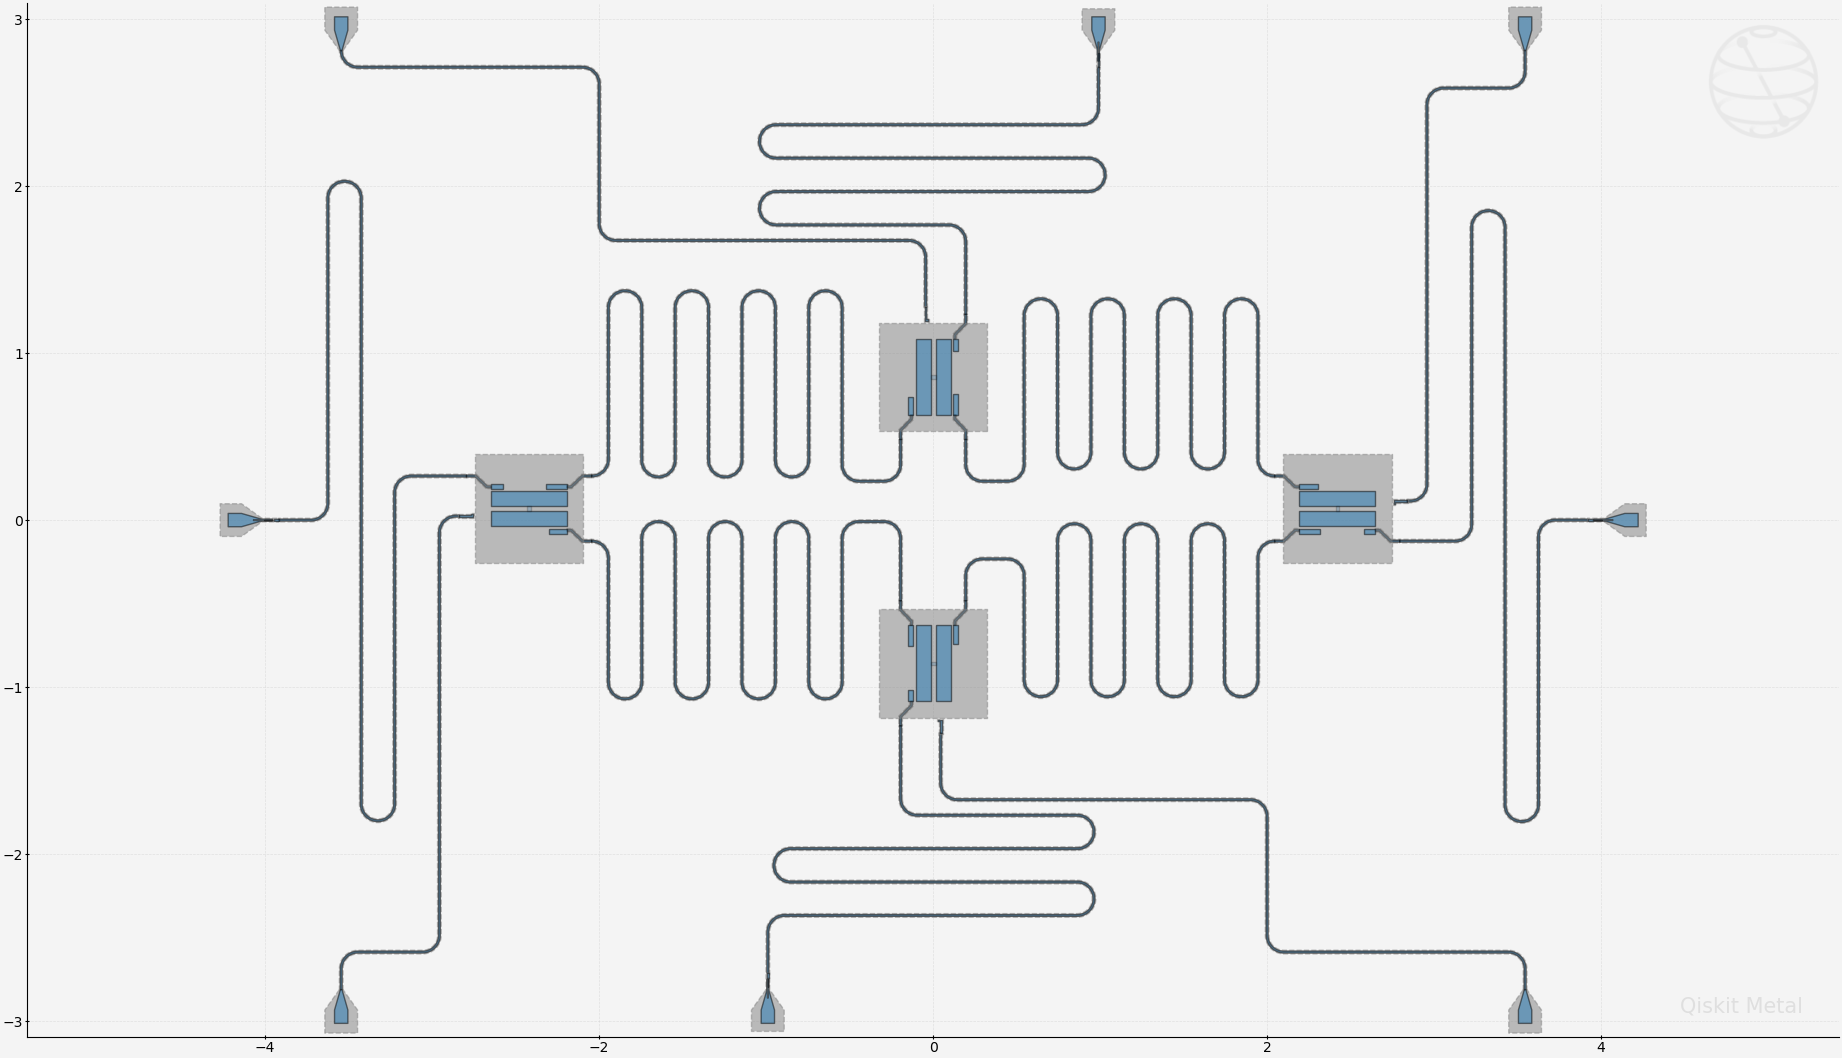

In [21]:
gui.figure.savefig("shot.png")

_disp_ops = dict(width=500)
display(Image("shot.png", **_disp_ops))

![Chip design](shot.png)

In [22]:
# # Closing the Qiskit Metal GUI
# gui.main_window.close()

In [23]:
# with open("four_qubit_chip_design_v2.py", "w") as f:
#     f.write(design.to_python_script())

In [24]:
# %run "./four_qubit_chip_design_v2.py"
# list(design.components.keys())

# Simulation and Analysis

All the qubit parameters can initially be tuned via a capacitance matrix and the lumped oscillator method (LOM).

As a reminder, our target parameters are (approximately):
- qubit frequency => 4.8, 5, 5.2, 5.4 GHz
- qubit anharmonicity => 300 MHz
- qubit-bus coupling ($g_{q - bus}$) => 80 MHz
- qubit-readout ($\chi_{qc}$ ) => 1 MHz
- bus frequency 
    - Q1 (bus_12, bus_14) => 5.8, 6.0 GHz
    - Q2 (bus_23, bus_12) => 6.2, 5.8 GHz
    - Q3 (bus_34, bus_23) => 6.4, 6.2 GHz
    - Q4 (bus_14, bus_34) => 6.0, 6.4 GHz
- readout frequencies => 6.8, 7, 7.2, 7.4 GHz
- readout Q_external => 2000 ????

## Qubits and Lumped Oscillator Model (LOM)

## Main-Pad Sweep — Tuning Anharmonicity (α)

LOM on the isolated qubit (Q3D), same as the χ/g connection-pad sweep, but here we vary the
**main island geometry** to tune EC and therefore the anharmonicity α ≈ −EC toward the
target **|α| ≈ 300 MHz**.

We sweep one parameter at a time, resetting to the design default (`pad_width=455um`,
`pad_height=90um`, `pad_gap=30um`) before the next:

- `pad_width`  → larger width → more island capacitance → smaller EC → smaller |α|
- `pad_height` → larger height → more island capacitance → smaller EC → smaller |α|
- `pad_gap`    → gap between the two islands (where the junction sits); changes how the
  islands couple → shifts EC

`Lj` is held fixed (14.745 nH): EC/α depend only on geometry, while `Lj` only moves `fQ`.
Each sweep is saved to `results/main_pad_anharmonicity_sweep/` and plotted as |α|/EC vs
geometry.

In [25]:
RUN_SIMULATIONS = False

In [26]:
from qiskit_metal.analyses.quantization import LOManalysis

lom_4qb = LOManalysis(design, "q3d")

In [27]:
lom_4qb.sim.setup.percent_error = 0.1
lom_4qb.sim.setup.max_passes = 20

lom_4qb.setup.freq_readout = 6.8  # GHz — Q1 readout target
lom_4qb.setup.freq_bus = [5.8, 6.0]  # GHz — bus_12, bus_14

OPEN_TERMINATIONS = [("Q1", "readout"), ("Q1", "bus_12"), ("Q1", "bus_14")]

for q in [q1, q2, q3, q4]:
    q.options.make_CL = False  # hide charge line from Q3D nets
design.rebuild()

In [28]:
# Design defaults — each parameter is reset to its default before the next sweep
MAIN_PAD_DEFAULTS = {"pad_width": "455um", "pad_height": "90um", "pad_gap": "30um"}

# ── Sweep ranges (one parameter at a time; island stays inside pocket = 650 µm)
main_pad_width_sweep = ["250um", "300um", "350um", "400um", "455um", "500um", "550um"]
main_pad_height_sweep = ["50um", "70um", "90um", "110um", "130um", "150um"]
main_pad_gap_sweep = ["10um", "20um", "30um", "40um", "50um", "60um"]


def sweep_main_pad(param, values):
    """Sweep one top-level main-pad option on Q1, recording anharmonicity metrics."""
    res = {}
    for val in values:
        q1.options[param] = val
        design.rebuild()
        lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
        lo = lom_4qb.lumped_oscillator
        res[val] = {
            "fQ": lo["fQ"],
            "EC_MHz": lo["EC"],
            "EJ": lo["EJ"],
            "alpha_MHz": lo["alpha"],
        }
    q1.options[param] = MAIN_PAD_DEFAULTS[param]  # reset to design value
    design.rebuild()
    return res

if RUN_SIMULATIONS:
    res_main_pad_width = sweep_main_pad("pad_width", main_pad_width_sweep)
    res_main_pad_height = sweep_main_pad("pad_height", main_pad_height_sweep)
    res_main_pad_gap = sweep_main_pad("pad_gap", main_pad_gap_sweep)

In [29]:
if RUN_SIMULATIONS:
    RESULTS_DIR = "results/main_pad_anharmonicity_sweep"
    os.makedirs(RESULTS_DIR, exist_ok=True)

    sweep_results = {
        "pad_width": (res_main_pad_width, "pad_width"),
        "pad_height": (res_main_pad_height, "pad_height"),
        "pad_gap": (res_main_pad_gap, "pad_gap"),
    }

    dfs = {}
    for key, (res, index_name) in sweep_results.items():
        df = pd.DataFrame(res).T
        df.index.name = index_name
        df.to_csv(f"{RESULTS_DIR}/Q1_main_{key}_sweep.csv")
        dfs[key] = df
        print(f"Saved {RESULTS_DIR}/Q1_main_{key}_sweep.csv  ({len(df)} rows)")

In [30]:
RESULTS_DIR = "results/main_pad_anharmonicity_sweep"

dfs = {}
for key in ["pad_width", "pad_height", "pad_gap"]:
    path = f"{RESULTS_DIR}/Q1_main_{key}_sweep.csv"
    df = pd.read_csv(path, index_col=0)
    dfs[key] = df
    print(f"Loaded {path}  ({len(df)} rows)")

Loaded results/main_pad_anharmonicity_sweep/Q1_main_pad_width_sweep.csv  (7 rows)
Loaded results/main_pad_anharmonicity_sweep/Q1_main_pad_height_sweep.csv  (6 rows)
Loaded results/main_pad_anharmonicity_sweep/Q1_main_pad_gap_sweep.csv  (6 rows)


In [31]:
import matplotlib.pyplot as plt

ALPHA_TARGET_MHZ = 300.0


def _um(index):
    return [float(v.replace("um", "")) for v in index]


panels = [
    ("pad_width", "Main pad width"),
    ("pad_height", "Main pad height"),
    ("pad_gap", "Main pad gap"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col")
for col, (key, label) in enumerate(panels):
    df = dfs[key]
    x = _um(df.index)

    ax_a = axes[0, col]
    ax_a.plot(x, df["alpha_MHz"].abs(), "o-", color="tab:purple")
    ax_a.axhline(
        ALPHA_TARGET_MHZ,
        color="tab:red",
        ls="--",
        lw=1,
        label=f"target |α| = {ALPHA_TARGET_MHZ:.0f} MHz",
    )
    ax_a.set_title(label)
    ax_a.grid(alpha=0.3)

    ax_ec = axes[1, col]
    ax_ec.plot(x, df["EC_MHz"], "s-", color="tab:orange")
    ax_ec.set_xlabel(f"{label} (µm)")
    ax_ec.grid(alpha=0.3)

axes[0, 0].set_ylabel("|α| (MHz)")
axes[1, 0].set_ylabel("EC (MHz)")
axes[0, 0].legend()
fig.suptitle(
    "Q1 main pad — anharmonicity |α| (target ≈ 300 MHz) and EC vs pad geometry"
)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/Q1_main_pad_anharmonicity_sweeps.png", dpi=150)
plt.show()

In [32]:
dfs["pad_width"]

,fQ,EC_MHz,EJ,alpha_MHz
pad_width,,,,
250um,6.628853,466.948268,13.6163,-569.972845
300um,6.227182,407.637594,13.6163,-488.473500
350um,5.888697,361.311843,13.6163,-426.785358
400um,5.605157,324.991281,13.6163,-379.558052
455um,5.334915,292.423001,13.6163,-338.028083
500um,5.136927,269.802056,13.6163,-309.627571
550um,4.936532,247.952309,13.6163,-282.536939


## EJ and Lj Targets — pad_width = 550 µm

**EC = 247,95 MHz** (same for all qubits, set by pad geometry)  
**|α| ≈ 282 MHz** (same for all qubits)

| Qubit | Target fQ (GHz) | EJ (GHz) | Lj (nH) | EJ/EC |
|-------|----------------|----------|---------|-------|
| Q1    | 4.8            | 11.086   | 14.745  | 37.9  |
| Q2    | 5.0            | 11.974   | 13.652  | 40.9  |
| Q3    | 5.2            | 12.896   | 12.676  | 44.1  |
| Q4    | 5.4            | 13.852   | 11.801  | 47.4  |

### Formula used

$$f_Q \approx \sqrt{8 E_J E_C} - E_C$$

$$E_J = \frac{(f_Q + E_C)^2}{8 E_C}$$

$$L_j = \frac{(\Phi_0 / 2\pi)^2}{E_J h}$$

where $\Phi_0 = 2.068 \times 10^{-15}$ Wb.

> **Note:** Bus resonator frequencies are set to [6.8, 7.0, 7.2, 7.4] GHz in the LOM setup.  


In [33]:
import numpy as np
from scipy.constants import e, h

# EC_MHz = sweep_data['350um']['variables']['lumped_oscillator']['EC']
EC_MHz = 247.952308539829
EC = EC_MHz * 1e6  # Hz
Phi0 = h / (2 * e)

target_fQ_GHz = [4.8, 5, 5.2, 5.4]

rows = []
for fQ_GHz in target_fQ_GHz:
    fQ = fQ_GHz * 1e9
    EJ = (fQ + EC) ** 2 / (8 * EC)
    Lj = (Phi0 / (2 * np.pi)) ** 2 / (EJ * h)
    rows.append(
        {
            "Qubit": f"Q{target_fQ_GHz.index(fQ_GHz) + 1}",
            "fQ (GHz)": round(fQ_GHz, 1),
            "EJ (GHz)": round(EJ / 1e9, 3),
            "Lj (nH)": round(Lj * 1e9, 3),
            "EJ/EC": round(EJ / EC, 1),
        }
    )

df = pd.DataFrame(rows)
print(f"EC  = {EC_MHz:.3f} MHz  (pad_width = 550um)")
print()
print(df.to_string(index=False))

EC  = 247.952 MHz  (pad_width = 550um)

Qubit  fQ (GHz)  EJ (GHz)  Lj (nH)  EJ/EC
   Q1       4.8    12.846   12.725   51.8
   Q2       5.0    13.884   11.773   56.0
   Q3       5.2    14.963   10.925   60.3
   Q4       5.4    16.081   10.165   64.9


In [34]:
optimal_pad_width = "550um"

for q in [q1, q2, q3, q4]:
    q.options.make_CL = False
    q.options.pad_width = optimal_pad_width
gui.rebuild()

In [35]:
lom_4qb.setup.junctions.Lj = 12.725

In [36]:
if RUN_SIMULATIONS:
    lom_4qb.run(
        components=["Q1"],
        open_terminations=OPEN_TERMINATIONS,
    )

In [37]:
if RUN_SIMULATIONS:
    lom_4qb.plot_convergence()
    lom_4qb.plot_convergence_chi()

In [38]:
if RUN_SIMULATIONS:
    lom_4qb.sim.capacitance_matrix

In [39]:
if RUN_SIMULATIONS:
    lom_4qb.lumped_oscillator

### Simulation also for connection pads on the qubits should be made
LOM analysis is specifically for the qubit, it cannot be used for the resonator!
- q1.options.connection_pads.readout.pad_gap
- q1.options.connection_pads.readout.pad_width
- q1.options.connection_pads.bus_01.pad_width
- q1.options.connection_pads.bus_02.pad_width

The relationships:

- Larger pad_width on connection pad → stronger coupling → higher g → higher χ
- Smaller pad_gap on connection pad → coupling pad closer to island → stronger coupling

## Connection Pad Sweep — Tuning χ and g

LOM on the isolated qubit (Q3D). The resonator is NOT simulated — its frequency
is an input (`freq_readout`, `freq_bus`). We use the known target values.

Sweep 1: `connection_pads.readout.pad_width` → tune χ_readout toward −1 MHz  
Sweep 2: `connection_pads.bus_12.pad_width` → tune g_bus toward 80 MHz

In [40]:
import numpy as np
import pandas as pd

if RUN_SIMULATIONS:
    optimal_pad_width = "550um"

    # ── Setup: Q1 targets ───────────────────────────────────────────────────────
    lom_4qb.setup.freq_readout = 6.8  # GHz — Q1 readout target
    lom_4qb.setup.freq_bus = [5.8, 6.0]  # GHz — bus_12, bus_14 targets
    lom_4qb.setup.junctions.Lj = 12.725  # nH  — Q1 targeting fQ = 4.8 GHz

    for q in [q1, q2, q3, q4]:
        q.options.make_CL = False  # hide charge line from Q3D nets
        q.options.pad_width = optimal_pad_width
    design.rebuild()

    OPEN_TERMINATIONS = [("Q1", "readout"), ("Q1", "bus_12"), ("Q1", "bus_14")]

    # ── Sweep 1: readout connection pad width ───────────────────────────────────
    readout_pad_width_sweep = [
        "50um",
        "60um",
        "70um",  # current/default
        "80um",
        "90um",
        "100um",
        "110um",
        "125um",
        "135um",
        "145um",
        "155um",
        "165um",
        "175um",
        "185um",
        "195um",
        "205um",
        "215um",
        "225um",
    ]
    res_readout_pad_width = {}

    # ── Sweep 2: readout connection pad gap ─────────────────────────────────────
    readout_pad_gap_sweep = [
        "2um",
        "5um",
        "8um",
        "10um",
        "12um",
        "15um",  # current/default
        "18um",
        "22um",
        "26um",
        "30um",
    ]
    res_readout_pad_gap = {}

    # ── Sweep 3: readout connection pad height ──────────────────────────────────
    readout_pad_height_sweep = [
        "15um",
        "20um",
        "25um",
        "30um",  # current/default
        "35um",
        "40um",
        "50um",
        "60um",
    ]
    res_readout_pad_height = {}

    for pw in readout_pad_width_sweep:
        q1.options.connection_pads.readout.pad_width = pw
        design.rebuild()
        lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
        lo = lom_4qb.lumped_oscillator
        res_readout_pad_width[pw] = {
            "fQ": lo["fQ"],
            "EC_MHz": lo["EC"],
            "chi_readout_MHz": lo["chi_in_MHz"][0],  # index 0 = readout mode
            "gbus_readout_MHz": lo["gbus"][0],
            "alpha_MHz": lo["alpha"],
        }

    q1.options.connection_pads.readout.pad_width = "70um"  # reset to design value
    design.rebuild()
    for pg in readout_pad_gap_sweep:
        q1.options.connection_pads.readout.pad_gap = pg
        design.rebuild()
        lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
        lo = lom_4qb.lumped_oscillator
        res_readout_pad_gap[pg] = {
            "fQ": lo["fQ"],
            "EC_MHz": lo["EC"],
            "chi_readout_MHz": lo["chi_in_MHz"][0],  # index 0 = readout mode
            "gbus_readout_MHz": lo["gbus"][0],
            "alpha_MHz": lo["alpha"],
        }

    q1.options.connection_pads.readout.pad_gap = "15um"  # reset to design value
    design.rebuild()
    for ph in readout_pad_height_sweep:
        q1.options.connection_pads.readout.pad_height = ph
        design.rebuild()
        lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
        lo = lom_4qb.lumped_oscillator
        res_readout_pad_height[ph] = {
            "fQ": lo["fQ"],
            "EC_MHz": lo["EC"],
            "chi_readout_MHz": lo["chi_in_MHz"][0],  # index 0 = readout mode
            "gbus_readout_MHz": lo["gbus"][0],
            "alpha_MHz": lo["alpha"],
        }

    q1.options.connection_pads.readout.pad_height = "30um"  # reset to design value
    design.rebuild()

In [41]:
if RUN_SIMULATIONS:
    RESULTS_DIR = "results/readout_pad_sweep"
    os.makedirs(RESULTS_DIR, exist_ok=True)

    sweep_results = {
        "pad_width": (res_readout_pad_width, "pad_width"),
        "pad_gap": (res_readout_pad_gap, "pad_gap"),
        "pad_height": (res_readout_pad_height, "pad_height"),
    }

    dfs = {}
    for key, (res, index_name) in sweep_results.items():
        df = pd.DataFrame(res).T
        df.index.name = index_name
        df.to_csv(f"{RESULTS_DIR}/Q1_readout_{key}_sweep.csv")
        dfs[key] = df
        print(f"Saved {RESULTS_DIR}/Q1_readout_{key}_sweep.csv  ({len(df)} rows)")

In [42]:
RESULTS_DIR = "results/readout_pad_sweep"

dfs = {}
for key in ["pad_width", "pad_height", "pad_gap"]:
    path = f"{RESULTS_DIR}/Q1_readout_{key}_sweep.csv"
    df = pd.read_csv(path, index_col=0)
    dfs[key] = df
    print(f"Loaded {path}  ({len(df)} rows)")

Loaded results/readout_pad_sweep/Q1_readout_pad_width_sweep.csv  (18 rows)
Loaded results/readout_pad_sweep/Q1_readout_pad_height_sweep.csv  (8 rows)
Loaded results/readout_pad_sweep/Q1_readout_pad_gap_sweep.csv  (10 rows)


In [43]:
import matplotlib.pyplot as plt

CHI_TARGET_MHZ = -1.0


def _um(index):
    return [float(v.replace("um", "")) for v in index]


panels = [
    ("pad_width", "Pad width"),
    ("pad_gap", "Pad gap"),
    ("pad_height", "Pad height"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col")
for col, (key, label) in enumerate(panels):
    df = dfs[key]
    x = _um(df.index)

    ax_chi = axes[0, col]
    ax_chi.plot(x, df["chi_readout_MHz"], "o-", color="tab:blue")
    ax_chi.axhline(
        CHI_TARGET_MHZ,
        color="tab:red",
        ls="--",
        lw=1,
        label=f"target χ = {CHI_TARGET_MHZ} MHz",
    )
    ax_chi.set_title(label)
    ax_chi.grid(alpha=0.3)

    ax_g = axes[1, col]
    ax_g.plot(x, df["gbus_readout_MHz"], "s-", color="tab:green")
    ax_g.set_xlabel(f"{label} (µm)")
    ax_g.grid(alpha=0.3)

axes[0, 0].set_ylabel("χ readout (MHz)")
axes[1, 0].set_ylabel("g readout (MHz)")
axes[0, 0].legend()
fig.suptitle("Q1 readout — χ (target ≈ −1 MHz) and g vs connection-pad geometry")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/Q1_readout_pad_geometry_sweeps.png", dpi=150)
plt.show()

In [44]:
dfs["pad_width"]

,fQ,EC_MHz,chi_readout_MHz,gbus_readout_MHz,alpha_MHz
pad_width,,,,,
50um,4.791484,248.577427,-0.163071,35.697813,-284.697982
60um,4.788603,248.260126,-0.204018,40.004785,-284.303564
70um,4.785806,247.952309,-0.248815,44.260564,-283.921004
80um,4.782909,247.633655,-0.298390,48.562421,-283.525052
90um,4.779930,247.306315,-0.351345,52.799179,-283.118385
100um,4.777198,247.006301,-0.408422,57.028943,-282.745737
110um,4.774147,246.671412,-0.467931,61.165042,-282.329848
125um,4.770072,246.224668,-0.563711,67.313620,-281.775179
135um,4.767298,245.920738,-0.630737,71.332925,-281.397911


In [45]:
optimal_readout_pad_width = "185um"

## Bus Connection-Pad Sweep — Tuning g (target ≈ 80 MHz)

LOM on isolated Q1 (Q3D), same setup as the readout sweep, but now we tune the two **bus**
connection pads so each qubit–bus coupling g lands near **80 MHz**.

Mode indices follow `OPEN_TERMINATIONS = [readout, bus_12, bus_14]`:
- **bus_12 → index 1** (5.8 GHz bus)
- **bus_14 → index 2** (6.0 GHz bus)

Levers: larger `pad_width` → stronger coupling → higher g; smaller `pad_gap` → pad closer to
the island → higher g; `pad_height` is a finer lever. We sweep width/gap/height one at a time
(resetting to defaults between), with the readout pad fixed at its tuned 185 µm.

In [46]:
if RUN_SIMULATIONS:
    optimal_pad_width = "550um"
    optimal_readout_pad_width = "185um"
    # ── Tuned-state setup ───────────────────────────────────────────────────────
    lom_4qb.setup.freq_readout = 6.8  # GHz
    lom_4qb.setup.freq_bus = [5.8, 6.0]  # GHz — bus_12, bus_14
    lom_4qb.setup.junctions.Lj = 12.725  # nH  — Q1

    for q in [q1, q2, q3, q4]:
        q.options.make_CL = False
        q.options.pad_width = optimal_pad_width  # fixed main pad (sets EC)
    # put the design in its χ-tuned state so bus g is measured against the real readout pad
    q1.options.connection_pads.readout.pad_width = optimal_readout_pad_width  # "185um"
    design.rebuild()

    OPEN_TERMINATIONS = [("Q1", "readout"), ("Q1", "bus_12"), ("Q1", "bus_14")]

    # Connection-pad defaults to reset to between sweeps
    BUS_DEFAULTS = {
        "bus_12": {"pad_width": "125um", "pad_gap": "15um", "pad_height": "30um"},
        "bus_14": {"pad_width": "110um", "pad_gap": "15um", "pad_height": "30um"},
    }
    BUS_MODE_INDEX = {"bus_12": 1, "bus_14": 2}  # per OPEN_TERMINATIONS order

    bus_width_sweep = [
        "100um",
        "125um",
        "150um",
        "162um",
        "175um",
        "200um",
        "225um",
        "250um",
    ]
    bus_gap_sweep = ["5um", "8um", "10um", "12um", "15um", "18um", "22um", "26um", "30um"]
    bus_height_sweep = ["15um", "20um", "25um", "30um", "35um", "40um", "50um", "60um"]
    BUS_SWEEPS = {
        "pad_width": bus_width_sweep,
        "pad_gap": bus_gap_sweep,
        "pad_height": bus_height_sweep,
    }


    def sweep_bus_pad(pad_name, param, values):
        """Sweep one geometry param of a bus connection pad on Q1; record g/χ for that mode."""
        mode_index = BUS_MODE_INDEX[pad_name]
        res = {}
        for v in values:
            q1.options.connection_pads[pad_name][param] = v
            design.rebuild()
            lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
            lo = lom_4qb.lumped_oscillator
            res[v] = {
                "fQ": lo["fQ"],
                "EC_MHz": lo["EC"],
                "g_bus_MHz": lo["gbus"][mode_index],
                "chi_bus_MHz": lo["chi_in_MHz"][mode_index],
                "alpha_MHz": lo["alpha"],
            }
        q1.options.connection_pads[pad_name][param] = BUS_DEFAULTS[pad_name][param]  # reset
        design.rebuild()
        return res


    res_bus = {"bus_12": {}, "bus_14": {}}
    for bus in ["bus_12", "bus_14"]:
        for param, values in BUS_SWEEPS.items():
            res_bus[bus][param] = sweep_bus_pad(bus, param, values)
            print(f"done {bus} {param} ({len(values)} pts)")

In [47]:
if RUN_SIMULATIONS:
    RESULTS_DIR = "results/bus_pad_sweep"
    os.makedirs(RESULTS_DIR, exist_ok=True)

    dfs_bus = {"bus_12": {}, "bus_14": {}}
    for bus in ["bus_12", "bus_14"]:
        for param, res in res_bus[bus].items():
            df = pd.DataFrame(res).T
            df.index.name = param
            df.to_csv(f"{RESULTS_DIR}/Q1_{bus}_{param}_sweep.csv")
            dfs_bus[bus][param] = df
            print(f"Saved {RESULTS_DIR}/Q1_{bus}_{param}_sweep.csv  ({len(df)} rows)")

In [48]:
if RUN_SIMULATIONS:
    for bus in ["bus_12", "bus_14"]:
        for param, res in res_bus[bus].items():
            print(param, res)

In [49]:
RESULTS_DIR = "results/bus_pad_sweep"

dfs_bus = {"bus_12": {}, "bus_14": {}}
for bus in ["bus_12", "bus_14"]:
    for param in ["pad_width", "pad_height", "pad_gap"]:
        path = f"{RESULTS_DIR}/Q1_{bus}_{param}_sweep.csv"
        df = pd.read_csv(path, index_col=0)
        dfs_bus[bus][param] = df
        print(f"Loaded {path}  ({len(df)} rows)")

Loaded results/bus_pad_sweep/Q1_bus_12_pad_width_sweep.csv  (8 rows)
Loaded results/bus_pad_sweep/Q1_bus_12_pad_height_sweep.csv  (8 rows)
Loaded results/bus_pad_sweep/Q1_bus_12_pad_gap_sweep.csv  (9 rows)
Loaded results/bus_pad_sweep/Q1_bus_14_pad_width_sweep.csv  (8 rows)
Loaded results/bus_pad_sweep/Q1_bus_14_pad_height_sweep.csv  (8 rows)
Loaded results/bus_pad_sweep/Q1_bus_14_pad_gap_sweep.csv  (9 rows)


In [50]:
import matplotlib.pyplot as plt

G_TARGET_MHZ = 80.0


def _um(index):
    return [float(v.replace("um", "")) for v in index]


panels = [
    ("pad_width", "Pad width"),
    ("pad_gap", "Pad gap"),
    ("pad_height", "Pad height"),
]

for bus in ["bus_12", "bus_14"]:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex="col")
    for col, (key, label) in enumerate(panels):
        df = dfs_bus[bus][key]
        x = _um(df.index)

        ax_g = axes[0, col]
        ax_g.plot(x, df["g_bus_MHz"].abs(), "o-", color="tab:green")
        ax_g.axhline(
            G_TARGET_MHZ,
            color="tab:red",
            ls="--",
            lw=1,
            label=f"target g = {G_TARGET_MHZ:.0f} MHz",
        )
        ax_g.set_title(label)
        ax_g.grid(alpha=0.3)

        ax_chi = axes[1, col]
        ax_chi.plot(x, df["chi_bus_MHz"], "s-", color="tab:blue")
        ax_chi.set_xlabel(f"{label} (µm)")
        ax_chi.grid(alpha=0.3)

    axes[0, 0].set_ylabel("|g| bus (MHz)")
    axes[1, 0].set_ylabel("χ bus (MHz)")
    axes[0, 0].legend()
    fig.suptitle(f"Q1 {bus} — |g| (target ≈ 80 MHz) and χ vs connection-pad geometry")
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/Q1_{bus}_g_geometry_sweeps.png", dpi=150)
    plt.show()

In [51]:
dfs_bus["bus_14"]["pad_width"]

,fQ,EC_MHz,g_bus_MHz,chi_bus_MHz,alpha_MHz
pad_width,,,,,
100um,4.757318,244.829195,-58.627110,-1.034432,-280.043545
125um,4.747758,243.786135,-69.167151,-1.414886,-278.750161
150um,4.738578,242.786829,-79.378840,-1.832657,-277.511790
162um,4.734129,242.303465,-84.177491,-2.044382,-276.913056
175um,4.729434,241.793899,-89.293365,-2.280976,-276.282054
200um,4.720540,240.830201,-98.935616,-2.755648,-275.089220
225um,4.714224,240.147185,-108.111226,-3.253361,-274.244223
250um,4.703420,238.981422,-117.410390,-3.763638,-272.802792


In [52]:
dfs_bus["bus_12"]["pad_width"]

,fQ,EC_MHz,g_bus_MHz,chi_bus_MHz,alpha_MHz
pad_width,,,,,
100um,4.760077,245.130688,47.070244,-0.916431,-280.417543
125um,4.753485,244.410700,55.608391,-1.261689,-279.524519
150um,4.746952,243.698235,63.861885,-1.641704,-278.641203
162um,4.743985,243.375174,67.740915,-1.835950,-278.240795
175um,4.740676,243.015005,71.888528,-2.053636,-277.794488
200um,4.734299,242.321867,79.681570,-2.490256,-276.935848
225um,4.728226,241.662815,87.152948,-2.942433,-276.119763
250um,4.722742,241.068602,94.496177,-3.420773,-275.384241


In [53]:
if RUN_SIMULATIONS:
    # ── Final combined check: set the chosen optimal widths and verify all targets together ──
    # Read these off the sweeps above (where each g curve crosses 80 MHz), then re-run this cell.
    optimal_pad_width = "550um"
    optimal_readout_pad_width = "185um"

    optimal_bus_12_pad_width = "200um"
    optimal_bus_14_pad_width = "150um"

    q1.options.pad_width = optimal_pad_width
    q1.options.connection_pads.readout.pad_width = optimal_readout_pad_width
    q1.options.connection_pads.bus_12.pad_width = optimal_bus_12_pad_width
    q1.options.connection_pads.bus_14.pad_width = optimal_bus_14_pad_width
    design.rebuild()

    lom_4qb.setup.junctions.Lj = 12.725
    lom_4qb.run(components=["Q1"], open_terminations=OPEN_TERMINATIONS)
    lo = lom_4qb.lumped_oscillator
    print(f"chi_readout = {lo['chi_in_MHz'][0]:+.3f} MHz   (target ≈ -1)")
    print(f"g_bus_12    = {lo['gbus'][1]:.3f} MHz   (target ≈ 80)")
    print(f"g_bus_14    = {lo['gbus'][2]:.3f} MHz   (target ≈ 80)")
    print(f"EC          = {lo['EC']:.3f} MHz")
    print(f"alpha       = {lo['alpha']:.3f} MHz")
    print(f"fQ          = {lo['fQ']:.4f} GHz")

Predicted Values

Transmon Properties
f_Q 4.718427 [GHz]
EC 240.601563 [MHz]
EJ 12.840519 [GHz]
alpha -274.806321 [MHz]
dispersion 5.324418 [KHz]
Lq 12.719869 [nH]
Cq 80.507491 [fF]
T1 125.226931 [us]

**Coupling Properties**

tCqbus1 7.249917 [fF]
gbus1_in_MHz 88.324004 [MHz]
χ_bus1 -0.907239 [MHz]
1/T1bus1 821.771393 [Hz]
T1bus1 193.673015 [us]

tCqbus2 7.801702 [fF]
gbus2_in_MHz 81.112942 [MHz]
χ_bus2 -2.498463 [MHz]
1/T1bus2 262.572435 [Hz]
T1bus2 606.137285 [us]

tCqbus3 -7.540399 [fF]
gbus3_in_MHz -81.173454 [MHz]
χ_bus3 -1.847975 [MHz]
1/T1bus3 186.588402 [Hz]
T1bus3 852.973399 [us]
Bus-Bus Couplings
gbus1_2 7.566730 [MHz]
gbus1_3 5.613143 [MHz]
gbus2_3 5.454261 [MHz]
chi_readout = -0.907 MHz   (target ≈ -1)
g_bus_12    = 81.113 MHz   (target ≈ 80)
g_bus_14    = -81.173 MHz   (target ≈ 80)
EC          = 240.602 MHz
alpha       = -274.806 MHz
fQ          = 4.7184 GHz

## Auto-Tune Connection Pads — Q2–Q4

Same isolated-Q LOM tuning as Q1, automated across Q2/Q3/Q4 — **pad_width only**, with each
qubit's `Lj` **recomputed from the current EC** (the 550 µm main pad). For each pad we sweep
width and report the interpolated width that hits its target:

- **readout** → χ ≈ −1 MHz
- **bus pads** → |g| ≈ 80 MHz (sign is convention; magnitude is the spec)

Per-qubit data is inlined here (no external module). These optimal widths + refreshed `Lj`
are the inputs the resonator/eigenmode + EPR stage consumes.

In [54]:
import numpy as np
import pandas as pd
from scipy.constants import e, h

QUBIT_PARAMS = {
    "Q2": {
        "freq_readout": 7.0,
        "freq_bus": [5.8, 6.2],
        "pads": ["readout", "bus_12", "bus_23"],
        "target_fQ": 5.0,
    },
    "Q3": {
        "freq_readout": 7.2,
        "freq_bus": [6.2, 6.4],
        "pads": ["readout", "bus_23", "bus_34"],
        "target_fQ": 5.2,
    },
    "Q4": {
        "freq_readout": 7.4,
        "freq_bus": [6.0, 6.4],
        "pads": ["readout", "bus_14", "bus_34"],
        "target_fQ": 5.4,
    },
}
QOBJ = {"Q2": q2, "Q3": q3, "Q4": q4}
    
if RUN_SIMULATIONS:
    optimal_pad_width = "550um"


    # Lock the main-pad state (550 µm, charge line hidden from Q3D)
    for q in [q1, q2, q3, q4]:
        q.options.make_CL = False
        q.options.pad_width = optimal_pad_width  # "550um"
    design.rebuild()


    def lj_for(fQ_GHz, EC_MHz):
        """Lj (nH) for a target qubit frequency given EC, via EJ=(fQ+EC)**2/(8*EC)."""
        EC, fQ = EC_MHz * 1e6, fQ_GHz * 1e9
        EJ = (fQ + EC) ** 2 / (8 * EC)
        return (h / (2 * e) / (2 * np.pi)) ** 2 / (EJ * h) * 1e9


    # Measure EC once at the current main pad (EC is geometry-only, so any Lj is fine here)
    _p = QUBIT_PARAMS["Q2"]
    lom_4qb.setup.freq_readout = _p["freq_readout"]
    lom_4qb.setup.freq_bus = _p["freq_bus"]
    lom_4qb.setup.junctions.Lj = 13.0
    lom_4qb.run(components=["Q2"], open_terminations=[("Q2", pad) for pad in _p["pads"]])
    EC_MHz = lom_4qb.lumped_oscillator["EC"]

    LJ = {q: lj_for(QUBIT_PARAMS[q]["target_fQ"], EC_MHz) for q in QUBIT_PARAMS}

    print(list(lom_4qb.sim.capacitance_matrix.index))
    print(f"EC at current main pad = {EC_MHz:.2f} MHz")
    print("Recomputed Lj (nH):", {q: round(v, 3) for q, v in LJ.items()})

In [55]:
# Lj = {"Q2": 11.773, "Q3": 10.925, "Q34": 10.165}
LJ = {"Q1": 12.725, "Q2": 11.773, "Q3": 10.925, "Q4": 10.165}
LJ

{'Q1': 12.725, 'Q2': 11.773, 'Q3': 10.925, 'Q4': 10.165}

In [56]:
import os

if RUN_SIMULATIONS:
    
    RESULTS_DIR = "results/all_qubits_pad_sweep"
    os.makedirs(RESULTS_DIR, exist_ok=True)

    readout_pad_width_sweep = [
        "50um",
        "60um",
        "70um",  # current/default
        "80um",
        "90um",
        "100um",
        "110um",
        "125um",
        "135um",
        "145um",
        "155um",
        "165um",
        "175um",
        "185um",
        "195um",
        "205um",
        "215um",
        "225um",
    ]
    bus_width_sweep = [
        "100um",
        "125um",
        "150um",
        "162um",
        "175um",
        "200um",
        "225um",
        "250um",
    ]


    def tune_pad_width(qname, pad, widths, target, metric):
        """Sweep one connection pad's width on `qname`; return (df, interpolated optimal width µm)."""
        p = QUBIT_PARAMS[qname]
        qobj = QOBJ[qname]
        open_terms = [(qname, pp) for pp in p["pads"]]
        idx = p["pads"].index(pad)
        lom_4qb.setup.freq_readout = p["freq_readout"]
        lom_4qb.setup.freq_bus = p["freq_bus"]
        lom_4qb.setup.junctions.Lj = LJ[qname]  # refreshed Lj
        orig = qobj.options.connection_pads[pad]["pad_width"]
        rows = {}
        for w in widths:
            qobj.options.connection_pads[pad]["pad_width"] = w
            design.rebuild()
            lom_4qb.run(components=[qname], open_terminations=open_terms)
            lo = lom_4qb.lumped_oscillator
            rows[w] = {
                "fQ": lo["fQ"],
                "EC_MHz": lo["EC"],
                "g_MHz": lo["gbus"][idx],
                "chi_MHz": lo["chi_in_MHz"][idx],
                "alpha_MHz": lo["alpha"],
            }
        qobj.options.connection_pads[pad]["pad_width"] = orig  # reset
        design.rebuild()
        df = pd.DataFrame(rows).T
        x = np.array([float(w.replace("um", "")) for w in widths])
        y = np.abs(df[metric].to_numpy(float))  # |g| or |chi|
        w_opt = float(np.interp(target, np.sort(y), x[np.argsort(y)]))
        if not (y.min() <= target <= y.max()):
            print(
                f"  WARN {qname} {pad}: target {target} outside swept range "
                f"[{y.min():.1f}, {y.max():.1f}] — widen the sweep"
            )
        return df, w_opt


    summary = []
    for qname in ["Q2", "Q3", "Q4"]: # TODO add the Q1?
        for pad in QUBIT_PARAMS[qname]["pads"]:
            if pad == "readout":
                df, w_opt = tune_pad_width(qname, pad, readout_pad_width_sweep, 1.0, "chi_MHz")
                tgt = "|chi|=1MHz"
            else:
                df, w_opt = tune_pad_width(qname, pad, bus_width_sweep, 80.0, "g_MHz")
                tgt = "|g|=80MHz"
            df.index.name = "pad_width"
            df.to_csv(f"{RESULTS_DIR}/{qname}_{pad}_pad_width_sweep.csv")
            summary.append(
                {
                    "qubit": qname,
                    "pad": pad,
                    "target": tgt,
                    "optimal_width_um": round(w_opt, 1),
                }
            )
            print(f"{qname:>3} {pad:<8} optimal width ≈ {w_opt:6.1f} um   ({tgt})")

    summary = pd.DataFrame(summary)
    summary.to_csv(f"{RESULTS_DIR}/optimal_widths_summary.csv", index=False)
    summary

In [57]:
import pandas as pd

RESULTS_DIR = "results/all_qubits_pad_sweep"

dfs_all = {"Q2": {}, "Q3": {}, "Q4": {}}
for qname in ["Q2", "Q3", "Q4"]:
    for pad in QUBIT_PARAMS[qname]["pads"]:
        path = f"{RESULTS_DIR}/{qname}_{pad}_pad_width_sweep.csv"
        df = pd.read_csv(path, index_col=0)
        dfs_all[qname][pad] = df
        print(f"Loaded {path}  ({len(df)} rows)")

# optional: also reload the optimal-width table
summary = pd.read_csv(f"{RESULTS_DIR}/optimal_widths_summary.csv")

Loaded results/all_qubits_pad_sweep/Q2_readout_pad_width_sweep.csv  (18 rows)
Loaded results/all_qubits_pad_sweep/Q2_bus_12_pad_width_sweep.csv  (8 rows)
Loaded results/all_qubits_pad_sweep/Q2_bus_23_pad_width_sweep.csv  (8 rows)
Loaded results/all_qubits_pad_sweep/Q3_readout_pad_width_sweep.csv  (18 rows)
Loaded results/all_qubits_pad_sweep/Q3_bus_23_pad_width_sweep.csv  (8 rows)
Loaded results/all_qubits_pad_sweep/Q3_bus_34_pad_width_sweep.csv  (8 rows)
Loaded results/all_qubits_pad_sweep/Q4_readout_pad_width_sweep.csv  (18 rows)
Loaded results/all_qubits_pad_sweep/Q4_bus_14_pad_width_sweep.csv  (8 rows)
Loaded results/all_qubits_pad_sweep/Q4_bus_34_pad_width_sweep.csv  (8 rows)


In [58]:
import matplotlib.pyplot as plt


def _um(index):
    return [float(v.replace("um", "")) for v in index]


for qname in ["Q2", "Q3", "Q4"]:
    pads = QUBIT_PARAMS[qname]["pads"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, pad in zip(axes, pads):
        df = dfs_all[qname][pad]
        x = _um(df.index)
        if pad == "readout":
            ax.plot(x, df["chi_MHz"], "s-", color="tab:blue")
            ax.axhline(-1.0, color="tab:red", ls="--", lw=1, label="target χ = -1 MHz")
            ax.set_ylabel("χ (MHz)")
        else:
            ax.plot(x, df["g_MHz"].abs(), "o-", color="tab:green")
            ax.axhline(80.0, color="tab:red", ls="--", lw=1, label="target |g| = 80 MHz")
            ax.set_ylabel("|g| (MHz)")
        ax.set_title(f"{qname} — {pad}")
        ax.set_xlabel("pad_width (µm)")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.suptitle(f"{qname} connection-pad width sweeps")
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/{qname}_pad_sweeps.png", dpi=150)
    plt.show()

In [59]:
if RUN_SIMULATIONS:
    # Apply the optimal widths + refreshed Lj, then verify each qubit hits its targets together.
    opt = summary.set_index(["qubit", "pad"])["optimal_width_um"]

    for qname in ["Q2", "Q3", "Q4"]:
        for pad in QUBIT_PARAMS[qname]["pads"]:
            QOBJ[qname].options.connection_pads[pad]["pad_width"] = (
                f"{opt[(qname, pad)]:.0f}um"
            )
    design.rebuild()

    verify_rows = []
    for qname in ["Q2", "Q3", "Q4"]:
        p = QUBIT_PARAMS[qname]
        lom_4qb.setup.freq_readout = p["freq_readout"]
        lom_4qb.setup.freq_bus = p["freq_bus"]
        lom_4qb.setup.junctions.Lj = LJ[qname]
        lom_4qb.run(components=[qname], open_terminations=[(qname, pp) for pp in p["pads"]])
        lo = lom_4qb.lumped_oscillator
        bus_a, bus_b = p["pads"][1], p["pads"][2]
        verify_rows.append({
            "qubit": qname,
            "fQ_GHz": lo["fQ"],
            "EC_MHz": lo["EC"],
            "alpha_MHz": lo["alpha"],
            "chi_readout_MHz": lo["chi_in_MHz"][0],
            "bus_a_pad": bus_a,
            "g_bus_a_MHz": abs(lo["gbus"][1]),
            "bus_b_pad": bus_b,
            "g_bus_b_MHz": abs(lo["gbus"][2]),
        })
        print(
            f"{qname}: fQ={lo['fQ']:.3f} GHz  EC={lo['EC']:.1f}  alpha={lo['alpha']:.1f}  "
            f"chi_ro={lo['chi_in_MHz'][0]:+.2f}  "
            f"|g|_{bus_a}={abs(lo['gbus'][1]):.1f}  |g|_{bus_b}={abs(lo['gbus'][2]):.1f}  (MHz)"
        )

    verify_df = pd.DataFrame(verify_rows)
    verify_df.to_csv(f"{RESULTS_DIR}/verify_results.csv", index=False)

In [60]:
verify_df = pd.read_csv(f"{RESULTS_DIR}/verify_results.csv")
verify_df

,qubit,fQ_GHz,EC_MHz,alpha_MHz,chi_readout_MHz,bus_a_pad,g_bus_a_MHz,bus_b_pad,g_bus_b_MHz
0,Q2,4.924308,241.446155,-274.120156,-0.959276,bus_12,83.755807,bus_23,76.767701
1,Q3,5.135312,242.764246,-274.159249,-0.965918,bus_23,83.236149,bus_34,76.796383
2,Q4,5.337029,243.083166,-273.113142,-0.947124,bus_14,77.065448,bus_34,83.334927


In [61]:
lom_4qb.sim.close()

## Resonator length sweep — eigenmode, all 8 CPWs

Generalize the single-`cpw1` eigenmode sweep above to **all 8 resonators**
(4 readout + 4 buses). For each resonator we sweep `total_length`, read the
simulated eigenmode nearest the target frequency, and **interpolate the length
that lands on target**.

Reuses the existing `design`, `sweep = Sweeping(design)` and `gui` objects —
ANSYS must be open with a project, exactly as for the `cpw1` sweep.

Suggested workflow: run **Cell B on readouts first** (`RES_SPECS[:4]`), confirm
each curve is converged + monotonic, then do the buses. 8 × 9 lengths × 15
passes is long.

In [62]:
verify_df = pd.read_csv(f"{RESULTS_DIR}/optimal_widths_summary_all_qubits_by_hand_Q1.csv")
opt = verify_df.set_index(["qubit", "pad"])["optimal_width_um"]
opt

qubit  pad    
Q1     readout    185.0
       bus_12     200.0
       bus_14     150.0
Q2     readout    173.7
       bus_12     162.0
       bus_23     164.5
Q3     readout    163.9
       bus_23     145.1
       bus_34     154.3
Q4     readout    154.8
       bus_14     163.6
       bus_34     135.7
Name: optimal_width_um, dtype: float64

In [63]:
QUBIT_PARAMS = {
    "Q1": {
        "freq_readout": 6.8,
        "freq_bus": [5.8, 6.0],
        "pads": ["readout", "bus_12", "bus_14"],
        "target_fQ": 4.8,
    },
    "Q2": {
        "freq_readout": 7.0,
        "freq_bus": [5.8, 6.2],
        "pads": ["readout", "bus_12", "bus_23"],
        "target_fQ": 5.0,
    },
    "Q3": {
        "freq_readout": 7.2,
        "freq_bus": [6.2, 6.4],
        "pads": ["readout", "bus_23", "bus_34"],
        "target_fQ": 5.2,
    },
    "Q4": {
        "freq_readout": 7.4,
        "freq_bus": [6.0, 6.4],
        "pads": ["readout", "bus_14", "bus_34"],
        "target_fQ": 5.4,
    },
}
QOBJ = {"Q1": q1, "Q2": q2, "Q3": q3, "Q4": q4}

optimal_pad_width = "550um"
pad_width = optimal_pad_width

for qname in ["Q1", "Q2", "Q3", "Q4"]:
    for pad in QUBIT_PARAMS[qname]["pads"]:
        QOBJ[qname].options.connection_pads[pad]["pad_width"] = (
            f"{opt[(qname, pad)]:.0f}um"
        )
    QOBJ[qname].options.pad_width = pad_width
    QOBJ[qname].options["hfss_inductance"] = f"Lj_{qname}"
    QOBJ[qname].options["hfss_capacitance"] = f"Cj_{qname}"
    QOBJ[qname].options.make_CL = True
design.rebuild()

In [64]:
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping

sweep = Sweeping(design)

In [65]:
# --- Cell A: spec table + eigenmode sweep helper ---------------------------
import os

import numpy as np
from qiskit_metal import Dict

# (name, render-components, ignored-jjs, target_GHz, center_length_mm)
# Centers are the analytic find_resonator_length values; the sweep brackets each
# by +/-0.6 mm so the target is bracketed in a single pass (no re-runs).
RES_SPECS = [
    ("Readout1", ["Q1", "Readout1", "Launch_RO_Q1"], [("Q1", "rect_jj")], 6.8, 8.79-0.8),
    ("Readout2", ["Q2", "Readout2", "Launch_RO_Q2"], [("Q2", "rect_jj")], 7.0, 8.54-0.8),
    ("Readout3", ["Q3", "Readout3", "Launch_RO_Q3"], [("Q3", "rect_jj")], 7.2, 8.31-0.8),
    ("Readout4", ["Q4", "Readout4", "Launch_RO_Q4"], [("Q4", "rect_jj")], 7.4, 8.08-0.8),
    ("cpw1", ["Q1", "Q2", "cpw1"], [("Q1", "rect_jj"), ("Q2", "rect_jj")], 5.8, 10.31-0.6),
    ("cpw2", ["Q3", "Q2", "cpw2"], [("Q3", "rect_jj"), ("Q2", "rect_jj")], 6.2, 9.64-0.6),
    ("cpw3", ["Q3", "Q4", "cpw3"], [("Q3", "rect_jj"), ("Q4", "rect_jj")], 6.4, 9.34-0.6),
    ("cpw4", ["Q1", "Q4", "cpw4"], [("Q1", "rect_jj"), ("Q4", "rect_jj")], 6.0, 9.97-0.6),
]

em_setup_args = Dict(min_freq_ghz=3, n_modes=2, max_passes=20, max_delta_f=0.1)
RESULTS_DIR = "results/resonator_length_sweep"
os.makedirs(RESULTS_DIR, exist_ok=True)


def length_grid(center_mm, span_mm=2, step_mm=0.2):
    """Inclusive grid of length strings centered on `center_mm` (+/-0.6mm, 13 pts)."""
    n = int(round(span_mm / step_mm))
    return [f"{center_mm - span_mm / 2 + i * step_mm:.2f}mm" for i in range(n + 1)]


def sweep_resonator(name, render, ignored, target_ghz, center_mm,
                    span_mm=1.2, step_mm=0.1):
    """Eigenmode sweep of one resonator's total_length.

    Returns (all_sweeps, return_code, rows). Each row keeps the mode nearest the
    target (freq_GHz, mode_idx, Q, kappa_MHz) plus every mode (modeK_GHz).
    """
    lengths = length_grid(center_mm, span_mm, step_mm)
    all_sweeps, rc = sweep.sweep_one_option_get_eigenmode_solution_data(
        name,
        "total_length",
        lengths,
        render,
        [],
        ignored,
        design_name=f"ResSweep_{name}",
        box_plus_buffer_render=False,
        setup_args=em_setup_args,
    )
    rows = []
    for L in lengths:
        if L not in all_sweeps:
            continue
        s = all_sweeps[L]
        freqs = np.atleast_1d(s["frequency"]).astype(float)
        Qs = np.atleast_1d(s["quality_factor"]).astype(float)
        kappas = np.atleast_1d(s["kappa_over_2pis"]).astype(float)  # GHz
        # m = int(np.argmin(np.abs(freqs - target_ghz)))  # mode nearest target
        m=0
        row = {
            "length_mm": float(L.rstrip("mm")),
            "freq_GHz": float(freqs[m]),  # chosen resonator mode
            "mode_idx": m,
            "Q": float(Qs[m]) if m < len(Qs) else np.nan,
            "kappa_MHz": float(kappas[m]) * 1e3 if m < len(kappas) else np.nan,
            "converged": bool(s["convergence"]),
        }
        for k in range(len(freqs)):  # keep every mode too
            row[f"mode{k}_GHz"] = float(freqs[k])
        rows.append(row)
    return all_sweeps, rc, rows

In [66]:
# --- Cell B: run sweeps, save results, interpolate target length ----------
# Expensive (ANSYS). Smoke-test with SPECS_TO_RUN = RES_SPECS[:1] first if you
# like; otherwise this is a single unattended pass. To re-plot/re-apply later
# WITHOUT re-running, restart the kernel and run Cell A then Cell B2 (load).
if RUN_SIMULATIONS:
    SPECS_TO_RUN = RES_SPECS  # e.g. RES_SPECS[:1] for a single-resonator smoke test
    summary = {}
    sweep_frames = {}
    for name, render, ignored, target, center in SPECS_TO_RUN:
        all_sweeps, rc, rows = sweep_resonator(name, render, ignored, target, center)

        # 1) full raw results (all modes, Q, kappa, convergence DataFrames) -> pickle
        pd.to_pickle(all_sweeps, f"{RESULTS_DIR}/{name}_all_sweeps.pkl")
        # 2) tidy per-length table (chosen mode + Q/kappa + every mode) -> CSV
        df = pd.DataFrame(rows)
        df.to_csv(f"{RESULTS_DIR}/{name}_length_sweep.csv", index=False)
        sweep_frames[name] = df

        d = df.sort_values("freq_GHz")  # freq decreases as length increases
        L_opt = float(np.interp(target, d.freq_GHz, d.length_mm))  # invert f(L)
        in_range = bool(df.length_mm.min() <= L_opt <= df.length_mm.max())
        summary[name] = {
            "target_GHz": target,
            "L_opt_mm": round(L_opt, 3),
            "in_range": in_range,
            "all_converged": bool(df.converged.all()),
        }
        flag = "" if in_range else "  <-- OUT OF RANGE, widen the grid"
        print(f"{name}: target {target} GHz -> {L_opt:.3f} mm   (rc={rc}){flag}")

    summary_df = pd.DataFrame(summary).T
    summary_df.to_csv(f"{RESULTS_DIR}/length_summary.csv")
    summary_df

In [67]:
# --- Cell B2: load saved results (re-entry WITHOUT re-running the sweep) ---
# Reopening the notebook later: run Cell A (cheap defs, no ANSYS), SKIP Cell B,
# run this to rebuild sweep_frames + summary from disk, then go to Cell C / D.
import glob
import os

import pandas as pd

sweep_frames = {}
for path in sorted(glob.glob(f"{RESULTS_DIR}/*_length_sweep.csv")):
    name = os.path.basename(path).replace("_length_sweep.csv", "")
    sweep_frames[name] = pd.read_csv(path)

summary_df = pd.read_csv(f"{RESULTS_DIR}/length_summary.csv", index_col=0)
summary = summary_df.to_dict("index")

# Optional: full raw results (all modes, Q, kappa, convergence tables)
all_sweeps_by_res = {
    name: pd.read_pickle(f"{RESULTS_DIR}/{name}_all_sweeps.pkl")
    for name in sweep_frames
    if os.path.exists(f"{RESULTS_DIR}/{name}_all_sweeps.pkl")
}

print(f"Loaded {len(sweep_frames)} resonators from {RESULTS_DIR}")
summary_df

Loaded 8 resonators from results/resonator_length_sweep


,target_GHz,L_opt_mm,in_range,all_converged
Readout1,6.8,7.915,True,True
Readout2,7.0,7.915,True,True
Readout3,7.2,7.330,True,True
Readout4,7.4,7.350,True,True
cpw1,5.8,9.690,True,True
cpw2,6.2,9.071,True,True
cpw3,6.4,8.657,True,True
cpw4,6.0,9.381,True,True


In [68]:
# --- Cell C2: plot BOTH eigenmodes per resonator (mode-switch diagnostic) ---
import matplotlib.pyplot as plt

targets = {n: t for n, _, _, t, _ in RES_SPECS}
sample = next(iter(sweep_frames.values()))
mode_cols = [c for c in sample.columns if c.startswith("mode") and c.endswith("_GHz")]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, (name, df) in zip(axes.flat, sweep_frames.items()):
    df = df.sort_values("length_mm")
    for col in mode_cols:
        if col in df and df[col].notna().any():
            ax.plot(df.length_mm, df[col], "o-", ms=4, label=col.replace("_GHz", ""))
    ax.scatter(df.length_mm, df.freq_GHz, s=90, facecolors="none",
               edgecolors="k", zorder=5, label="chosen (mode_idx)")
    t = targets.get(name)
    if t is not None:
        ax.axhline(t, ls="--", c="r", lw=1, label=f"target {t} GHz")
    if name in summary:
        ax.axvline(summary[name]["L_opt_mm"], ls=":", c="g", lw=1)
    ax.set_title(name); ax.set_xlabel("length (mm)"); ax.set_ylabel("freq (GHz)")
    ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/resonator_modes_both.png", dpi=150)
plt.show()

In [69]:
# --- Cell D: apply tuned lengths back to the design -----------------------
for name, s in summary.items():
    design.components[name].options.total_length = f"{s['L_opt_mm']:.3f}mm"
    print(f"{name}.total_length <- {s['L_opt_mm']:.3f}mm")
gui.rebuild()

Readout1.total_length <- 7.915mm
Readout2.total_length <- 7.915mm
Readout3.total_length <- 7.330mm
Readout4.total_length <- 7.350mm
cpw1.total_length <- 9.690mm
cpw2.total_length <- 9.071mm
cpw3.total_length <- 8.657mm
cpw4.total_length <- 9.381mm


### Resonator and Eigenmode Simulations

We will focus on `bus_12` for this step.

In [70]:
from qiskit_metal.analyses.quantization import EPRanalysis

cpw1_EPR = EPRanalysis(design, "hfss")

In [71]:
# design.components['cpw1'].options.total_length = f"{s['L_opt_mm']:.3f}mm"

In [72]:
cpw1_EPR.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 1,
 'n_modes': 1,
 'max_delta_f': 0.5,
 'max_passes': 10,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj': '10 nH', 'Cj': '0 fF'}}

In [73]:
cpw1_EPR.sim.renderer.options

{'Lj': '10nH',
 'Cj': 0,
 '_Rj': 0,
 'max_mesh_length_jj': '7um',
 'max_mesh_length_port': '7um',
 'project_path': None,
 'project_name': None,
 'design_name': None,
 'x_buffer_width_mm': 0.2,
 'y_buffer_width_mm': 0.2,
 'wb_threshold': '400um',
 'wb_offset': '0um',
 'wb_size': 5,
 'plot_ansys_fields_options': {'name': 'NAME:Mag_E1',
  'UserSpecifyName': '0',
  'UserSpecifyFolder': '0',
  'QuantityName': 'Mag_E',
  'PlotFolder': 'E Field',
  'StreamlinePlot': 'False',
  'AdjacentSidePlot': 'False',
  'FullModelPlot': 'False',
  'IntrinsicVar': "Phase='0deg'",
  'PlotGeomInfo_0': '1',
  'PlotGeomInfo_1': 'Surface',
  'PlotGeomInfo_2': 'FacesList',
  'PlotGeomInfo_3': '1'}}

In [74]:
if RUN_SIMULATIONS: 
    cpw1_EPR.sim.setup.n_modes = 2
    cpw1_EPR.sim.setup.max_delta_f = 0.025
    cpw1_EPR.sim.setup.max_passes = 20
    cpw1_EPR.sim.run_sim(name="CPW1_Sim", components=['Q1','Q2','cpw1'], 
                    ignored_jjs = [('Q1','rect_jj'),('Q2','rect_jj')], 
                    box_plus_buffer = True)

In [75]:
if RUN_SIMULATIONS: 
    cpw1_EPR.sim.plot_convergences()

In [76]:
if RUN_SIMULATIONS: 
    cpw1_EPR.get_frequencies()

In [77]:
if RUN_SIMULATIONS: 
    cpw1_EPR.sim.plot_fields('main', eigenmode=1)
    #bus_02_EPR.sim.save_screenshot()

In [78]:
cpw1_EPR.sim.close()

### EPR Analysis

In [79]:
from qiskit_metal.analyses.quantization import EPRanalysis

three_mode_EPR = EPRanalysis(design, "hfss")

In [80]:
three_mode_EPR.setup

{'junctions': {'jj': {'Lj_variable': 'Lj',
   'Cj_variable': 'Cj',
   'rect': '',
   'line': ''}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj'}

In [81]:
LJ

{'Q1': 12.725, 'Q2': 11.773, 'Q3': 10.925, 'Q4': 10.165}

In [82]:
def newton_lj(lj_old, f_measured, f_target, EC):
    """Near-exact Lj update to hit target fQ.
    All frequencies in GHz, Lj in nH. EC is the dressed charging energy
    (use |alpha| from the same EPR run).
    """
    return lj_old * ((f_measured + EC) / (f_target + EC)) ** 2

In [83]:
newton_lj(12.725, 4.6, 4.8, 0.2479)

11.736635335522184

In [84]:
three_mode_EPR.sim.setup.n_modes = 5 # TODO increase to seven?
three_mode_EPR.sim.setup.max_passes = 15
three_mode_EPR.sim.setup.max_delta_f = 0.05
three_mode_EPR.sim.setup.vars = Dict(
    Lj_Q1="11.735 nH", # 12 nH gives correct frequency on the Q1 
    Cj_Q1="0 fF",  # 14.745 nH
    # Lj_Q2="11.773 nH",
    # Cj_Q2="0 fF",  # 13.652
    # Lj_Q3="10.925 nH",
    # Cj_Q3="0 fF",
    # Lj_Q4="10.165 nH",
    # Cj_Q4="0 fF",
)

In [85]:
if RUN_SIMULATIONS:
    three_mode_EPR.sim.run_sim(
        name="Q1_full",
        components=["Q1", "cpw1", "cpw4", "Readout1", "Launch_RO_Q1", "Launch_CL_Q1", "Charge_Line1"],
        open_terminations=[("cpw1", "end"), ("cpw4", "end")],
        box_plus_buffer=False,
    )

In [86]:
# three_mode_EPR.setup.cos_trunc = 6 #8 # anharmonicity α accuracy
# three_mode_EPR.setup.fock_trunc = 6 #4  # most important reduction, higher order corrections to fQ, g, χ 4 is sufficient for fQ and g

In [87]:
if RUN_SIMULATIONS:
    three_mode_EPR.sim.plot_convergences()

In [88]:
if RUN_SIMULATIONS:
    three_mode_EPR.get_frequencies()

In [89]:
if RUN_SIMULATIONS:
    three_mode_EPR.sim.plot_fields("main", eigenmode=2)

In [90]:
if RUN_SIMULATIONS:
    three_mode_EPR.del_junction()

    three_mode_EPR.add_junction(
        "jj1", "Lj_Q1", "Cj_Q1", rect="JJ_rect_Lj_Q1_rect_jj", line="JJ_Lj_Q1_rect_jj_"
    )
    # three_mode_EPR.add_junction(
    #     "jj2", "Lj_Q2", "Cj_Q2", rect="JJ_rect_Lj_Q2_rect_jj", line="JJ_Lj_Q2_rect_jj_"
    # )
    # eig_4qb_ps.add_junction('jj3', 'Lj_Q3', 'Cj_Q3', rect='JJ_rect_Lj_Q3_rect_jj', line='JJ_Lj_Q3_rect_jj_')
    # eig_4qb_ps.add_junction('jj4', 'Lj_Q4', 'Cj_Q4', rect='JJ_rect_Lj_Q4_rect_jj', line='JJ_Lj_Q4_rect_jj_')
    three_mode_EPR.setup.sweep_variable = "variation"  # 'variation'

In [91]:
if RUN_SIMULATIONS:
    three_mode_EPR.run_epr()

In [92]:
if RUN_SIMULATIONS:
    qa  = three_mode_EPR.sim.renderer.epr_quantum_analysis
    res = qa.results[list(qa.results)[0]]
    chid = np.diag(np.abs(np.asarray(res["chi_ND"], float)))
    chid

## Why `run_epr` qubit frequencies sit below `run_sim`

|  | Q1 | Q2 | bus (cpw1) |
|---|---|---|---|
| **`run_sim`** — linear eigenmode | 4.904 GHz | 5.117 GHz | 5.826 GHz |
| **`run_epr`** — ND (real $f_{01}$) | 4.662 GHz | 4.874 GHz | 5.822 GHz |
| **shift** | −242 MHz | −243 MHz | −4 MHz |

The two steps differ in **how the Josephson junction is modeled**:

- **`run_sim`** treats the junction as a **linear inductor** $L_J$. The qubit mode is then a
  harmonic ($LC$) oscillator, and HFSS returns its **plasma frequency**
  $\omega_p = 1/\sqrt{L_J C_\Sigma} \approx \sqrt{8 E_J E_C}$ — a *parabolic-well* frequency.

- **`run_epr`** restores the nonlinearity. The real junction potential $-E_J\cos\varphi$ is
  **softer than a parabola**, so the well is effectively wider and the transition energies drop.
  Numerical diagonalization gives the true 0→1 transition:

$$ f_{01} \approx \omega_p - E_C $$

So each junction mode is pulled **down by roughly one $E_C$** (the anharmonicity, ≈ 240–255 MHz here).
Check: $4.904 - 4.662 = 0.242$ GHz and $5.117 - 4.874 = 0.243$ GHz — both ≈ $E_C$. Textbook transmon.

**The bus confirms the mechanism.** It shifts only −4 MHz because the anharmonic correction acts
only where there is **junction participation**: the qubit modes have $p \approx 0.96$ (full $E_C$
pull-down), while the bus has $p \approx 0.01$ (essentially linear, so EPR ≈ sim).

**Takeaway:** the physical qubit frequency is the **`run_epr` ND value** (what you'd measure and
compare to the 4.8 / 5.0 GHz targets). The `run_sim` linear value is an intermediate plasma
frequency, always ~one $E_C$ high for a junction mode — which is why the $L_J$ trim is keyed off
the EPR frequencies, not the linear ones.


TODO NEEDS TRIMMING
f01 ≈ √(8 EJ EC) − EC, with EC = e²/2C_Σ. In the full coupled chip the qubit has more total capacitance than the isolated LOM extraction assumed (extra coupling to the bus pad, neighbors, distributed ground). More C_Σ → smaller EC → lower f01 at the same Lj. That's exactly the direction you saw (4.66/4.87 vs 4.8/5.0). The bus also dresses the qubits, pulling them slightly. None of this is visible to LOM, so LOM's Lj was always going to need a touch-up.

## Auto-tune Lj for Q2, Q3, Q4 (EPR + Newton loop)

Outer loop over Q2/Q3/Q4; inner loop `run_sim -> run_epr -> newton_lj` until |error| <= 15 MHz.
Q1 is already done (`Lj_Q1 = 11.737 nH`). The qubit mode is found by its largest anharmonicity
(`chi_ND` diagonal), and EC is read from that measured anharmonicity each step (self-calibrating).
`open_terminations` open each bus's far (absent-qubit) end, derived from the `connect()` wiring:
cpw1 start=Q1/end=Q2, cpw2 start=Q3/end=Q2, cpw3 start=Q3/end=Q4, cpw4 start=Q1/end=Q4.

Needs `np`, `Dict`, and `newton_lj` in scope, and the ANSYS connection **open** (run before
`three_mode_EPR.sim.close()`). Each iteration is a full eigenmode solve. After it finishes,
`final_Lj` holds all four Lj -> set them in `setup.vars` and rebuild for the validation run.

In [93]:
LJ

{'Q1': 12.725, 'Q2': 11.773, 'Q3': 10.925, 'Q4': 10.165}

In [94]:
three_mode_EPR.setup

{'junctions': {'jj': {'Lj_variable': 'Lj',
   'Cj_variable': 'Cj',
   'rect': '',
   'line': ''}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj'}

In [ ]:
# ===== Final verification: one EPR per qubit at its tuned Lj =====
import numpy as np

TOL_MHZ  = 20
MAX_ITERS = 4
# Each qubit renders its own metal + readout + charge line + the TWO buses it
# touches + the NEIGHBOR qubit pads those buses terminate into. Neighbor
# junctions are NOT added as EPR junctions (their pads just provide the correct
# EM boundary so the bus modes sit at ~5.8-6.4 GHz instead of collapsing into
# an open stub near the qubit). No open_terminations needed on the buses.
QTUNE = {
    # "Q1": dict(target_GHz=4.8, Lj0=11.6600,
    #         components=["Q1","Readout1","Launch_RO_Q1","Charge_Line1","Launch_CL_Q1",
    #                     "cpw1","cpw4","Q2","Q4"],
    #         open_terms=[],
    #         jj=("jj1","Lj_Q1","Cj_Q1","JJ_rect_Lj_Q1_rect_jj","JJ_Lj_Q1_rect_jj_")),
    # "Q2": dict(target_GHz=5.0, Lj0=11.7730,
    #         components=["Q2","Readout2","Launch_RO_Q2","Charge_Line2","Launch_CL_Q2",
    #                     "cpw1","cpw2","Q1","Q3"],
    #         open_terms=[],
    #         jj=("jj2","Lj_Q2","Cj_Q2","JJ_rect_Lj_Q2_rect_jj","JJ_Lj_Q2_rect_jj_")),
    "Q3": dict(target_GHz=5.2, Lj0=9.9930,
            components=["Q3","Readout3","Launch_RO_Q3","Charge_Line3","Launch_CL_Q3",
                        "cpw2","cpw3","Q2","Q4"],
            open_terms=[],
            jj=("jj3","Lj_Q3","Cj_Q3","JJ_rect_Lj_Q3_rect_jj","JJ_Lj_Q3_rect_jj_")),
    # "Q4": dict(target_GHz=5.4, Lj0=9.9390,
    #         components=["Q4","Readout4","Launch_RO_Q4","Charge_Line4","Launch_CL_Q4",
    #                     "cpw3","cpw4","Q3","Q1"],
    #         open_terms=[],
    #         jj=("jj4","Lj_Q4","Cj_Q4","JJ_rect_Lj_Q4_rect_jj","JJ_Lj_Q4_rect_jj_")),
}

# --- neighbor junction Lj values, so we can pin neighbor junctions HIGH -------
# Setting a neighbor's Lj very large (~1 uH) makes its transmon mode drop far
# below 3 GHz (out of the n_modes window) instead of appearing near the target
# qubit and re-introducing a hybridization partner. Only the swept qubit's
# junction is added to the EPR analysis.
NEIGH_LJ = {  # component-metal name -> its Lj variable name
    "Q1": "Lj_Q1", "Q2": "Lj_Q2", "Q3": "Lj_Q3", "Q4": "Lj_Q4",
}
NEIGH_CJ = {
    "Q1": "Cj_Q1", "Q2": "Cj_Q2", "Q3": "Cj_Q3", "Q4": "Cj_Q4"
}

three_mode_EPR.sim.setup.min_freq_ghz = 3
three_mode_EPR.sim.setup.n_modes      = 5
three_mode_EPR.sim.setup.max_delta_f  = 0.1
three_mode_EPR.sim.setup.max_passes   = 18
three_mode_EPR.setup.cos_trunc  = 8
three_mode_EPR.setup.fock_trunc = 7

def extract(res, jj_participates_thresh=0.5):
    """Select the qubit mode by JUNCTION PARTICIPATION, not argmax, and flag
    hybridization (two modes both carrying significant junction participation)."""
    P_normed = np.abs(np.asarray(res["Pm_normed"], float)).ravel()

    P_raw = np.abs(np.asarray(res["Pm_raw"], float)).ravel() if "Pm_raw" in res else P_normed

    # qubit mode = highest junction participation
    order = np.argsort(P_raw)[::-1]
    q = int(order[0])

    # hybridization check: is there a SECOND mode with comparable participation?
    hybridized = False
    if len(order) > 1:
        p1, p2 = P_raw[order[0]], P_raw[order[1]]
        if p1 > 0.1 and p2 > jj_participates_thresh * p1:
            hybridized = True

    f01  = float(np.asarray(res["f_ND"], float)[q]) / 1e3
    a_O1 = abs(float(np.diag(np.asarray(res["chi_O1"], float))[q]))
    a_ND = abs(float(np.diag(np.asarray(res["chi_ND"], float))[q]))
    alpha = a_ND if (100 < a_ND < 400) else a_O1

    cross_kerr  = np.abs(np.asarray(res["chi_O1"], float)[q]).copy(); cross_kerr[q] = 0
    clean = (P_raw[q] > 0.7) and (not hybridized)
    return q, f01, alpha, P_raw[q], cross_kerr.max(), clean, hybridized


final = {}
for qn, cfg in QTUNE.items():
    print(f"\n########## {qn} -> {cfg['target_GHz']} GHz ##########")
    Lj = cfg["Lj0"]
    for it in range(1, MAX_ITERS + 1):
        Lj_used = Lj
        # swept qubit at its tuned Lj; neighbor junctions pinned high + Cj=0
        vars_ = {cfg["jj"][1]: f"{Lj:.4f} nH", cfg["jj"][2]: "0 fF"}
        for comp in cfg["components"]:
            if comp in NEIGH_LJ and comp != qn:      # a neighbor qubit metal
                vars_[NEIGH_LJ[comp]] = "1000 nH"    # push neighbor mode < 3 GHz
                vars_[NEIGH_CJ[comp]] = "0 fF"
        three_mode_EPR.sim.setup.vars = Dict(**vars_)

        three_mode_EPR.sim.run_sim(name=f"{qn}_final", components=cfg["components"],
                                open_terminations=cfg["open_terms"], box_plus_buffer=False)

        three_mode_EPR.setup.junctions.clear()
        three_mode_EPR.add_junction(cfg["jj"][0], cfg["jj"][1], cfg["jj"][2],
                                    rect=cfg["jj"][3], line=cfg["jj"][4])
        three_mode_EPR.sim.renderer.pinfo.junctions.clear()
        three_mode_EPR.setup.sweep_variable = "variation"
        three_mode_EPR.run_epr()

        res = three_mode_EPR.sim.renderer.epr_quantum_analysis.results
        res = res[list(res)[0]]
        q, f01, alpha, Pq, max_cross_kerr, clean, hybridized = extract(res)
        err = (cfg["target_GHz"] - f01) * 1e3
        tag = "on-target" if abs(err) <= TOL_MHZ else "OFF-TARGET"
        flags = ""
        if not clean: 
            flags += "  NOT CLEAN"
        if hybridized:       
            flags += "  HYBRIDIZED"
        print(f"  Lj={Lj_used:.4f} nH -> f01={f01*1e3:.1f} MHz  alpha={alpha:.0f} MHz  "
            f"P={Pq:.2f} max_cross_kerr={max_cross_kerr:.1f}  err={err:+.1f} MHz  {tag}{flags}")
        if abs(err) <= TOL_MHZ:
            print(f"  CONVERGED  {cfg['jj'][1]} = {Lj_used:.4f} nH") 
            break
        
        if not clean or hybridized:   # Don't Newton-step on an unreliable (unclean/hybridized) f01
            print("     STOP: unclean/hybridized — not iterating on unreliable f01")
            break
        
        Lj = newton_lj(Lj, f01, cfg["target_GHz"], alpha/1e3)
    final[qn] = dict(Lj=round(Lj_used,4), f01=round(f01,4), alpha=round(alpha,1), cross_kerr=round(max_cross_kerr,1),
                    clean=clean, hybridized=hybridized)

print("\n=== Final results ===")
print(f"{'Qubit':6} {'Lj (nH)':>9} {'f01 (GHz)':>10} {'|alpha| (MHz)':>13}  status")
for qn in ["Q1","Q2","Q3","Q4"]:
    r = final.get(qn, {})
    status = "ok" if r.get("clean") else ("HYBRID" if r.get("hybridized") else "CHECK")
    print(f"{qn:6} {r.get('Lj',float('nan')):9.4f} {r.get('f01',float('nan')):10.4f} "
        f"{r.get('alpha',float('nan')):13.1f}  {status}")


########## Q3 -> 5.2 GHz ##########


INFO 08:44PM [connect_design]: 	Opened active design
	Design:    Q3_final_hfss [Solution type: Eigenmode]
WARNING 08:44PM [connect_setup]: 	No design setup detected.
WARNING 08:44PM [connect_setup]: 	Creating eigenmode default setup.
INFO 08:44PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 08:44PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 08:44PM [analyze]: Analyzing setup Setup
09:42PM 58s INFO [get_f_convergence]: Saved convergences to c:\Users\giann\Projects\quantum-metal\qiskit-metal-simulations\hfss_eig_f_convergence.csv


Design "Q3_final_hfss" info:
	# eigenmodes    5
	# variations    1
Design "Q3_final_hfss" info:
	# eigenmodes    5
	# variations    1

        energy_elec_all       = 2.26336104871009e-23
        energy_elec_substrate = 2.07315655006713e-23
        EPR of substrate = 91.6%

        energy_mag    = 2.26332766436124e-23
        energy_mag % of energy_elec_all  = 100.0%
        

Variation 0  [1/1]

  Mode 0 at 3.79 GHz   [1/5]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
                0.0%  1.132e-23 1.132e-23

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_0j   sign s_0j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 98.88%
	jj3             1.25305e-05  (+)        1.42027e-07
		(U_tot_cap-U_tot_ind)/mean=0.00%
Calculating Qdielectric_main for mode 0 (0/4)


  sol = sol.append(self.get_Qdielectric(



p_dielectric_main_0 = 0.9159636953408917

  Mode 1 at 5.10 GHz   [2/5]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
              100.0%  3.278e-27 4.637e-32

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_1j   sign s_1j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 97.99%
	jj3             1.68817e-08  (+)        3.47013e-10
		(U_tot_cap-U_tot_ind)/mean=100.00%
Calculating Qdielectric_main for mode 1 (1/4)


...

variation,0
0,3790.17
1,5104.13
2,5105.57
3,5303.13
4,5569.33


#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

0         1         2         3         4
variation                                                    
0         0  3.72e-08  4.31e-10  3.97e-10  6.21e-03  7.81e-04
          1  4.31e-10 -4.01e-11 -1.35e-10 -3.05e-04  1.02e-06
          2  3.97e-10 -1.35e-10 -1.96e-10 -3.14e-04  1.14e-06
          3  6.21e-03 -3.05e-04 -3.14e-04 -2.40e+02  4.87e+02
          4  7.81e-04  1.02e-06  1.14e-06  4.87e+02  1.79e+00

  Lj=9.9930 nH -> f01=5569.3 MHz  alpha=75 MHz  P=0.54 max_cross_kerr=109.7  err=-369.3 MHz  OFF-TARGET  NOT CLEAN  HYBRIDIZED
     STOP: unclean/hybridized — not iterating on unreliable f01

=== Final results ===
Qubit    Lj (nH)  f01 (GHz) |alpha| (MHz)  status
Q1           nan        nan           nan  CHECK
Q2           nan        nan           nan  CHECK
Q3        9.9930     5.5693          74.9  HYBRID
Q4           nan        nan           nan  CHECK


In [99]:
# ===== Final verification: one EPR per qubit at its tuned Lj =====
import numpy as np

TOL_MHZ = 20

# Each qubit renders its own metal + readout + charge line + the TWO buses it
# touches + the NEIGHBOR qubit pads those buses terminate into. Neighbor
# junctions are NOT added as EPR junctions (their pads just provide the correct
# EM boundary so the bus modes sit at ~5.8-6.4 GHz instead of collapsing into
# an open stub near the qubit). No open_terminations needed on the buses.
QTUNE = {
    "Q1": dict(target_GHz=4.8, Lj0=11.6600,
               components=["Q1","Readout1","Launch_RO_Q1","Charge_Line1","Launch_CL_Q1",
                           "cpw1","cpw4","Q2","Q4"],
               open_terms=[],
               jj=("jj1","Lj_Q1","Cj_Q1","JJ_rect_Lj_Q1_rect_jj","JJ_Lj_Q1_rect_jj_")),
    # "Q2": dict(target_GHz=5.0, Lj0=11.7730,
    #            components=["Q2","Readout2","Launch_RO_Q2","Charge_Line2","Launch_CL_Q2",
    #                        "cpw1","cpw2","Q1","Q3"],
    #            open_terms=[],
    #            jj=("jj2","Lj_Q2","Cj_Q2","JJ_rect_Lj_Q2_rect_jj","JJ_Lj_Q2_rect_jj_")),
    # "Q3": dict(target_GHz=5.2, Lj0=9.9930,
    #            components=["Q3","Readout3","Launch_RO_Q3","Charge_Line3","Launch_CL_Q3",
    #                        "cpw2","cpw3","Q2","Q4"],
    #            open_terms=[],
    #            jj=("jj3","Lj_Q3","Cj_Q3","JJ_rect_Lj_Q3_rect_jj","JJ_Lj_Q3_rect_jj_")),
    # "Q4": dict(target_GHz=5.4, Lj0=9.9390,
    #            components=["Q4","Readout4","Launch_RO_Q4","Charge_Line4","Launch_CL_Q4",
    #                        "cpw3","cpw4","Q3","Q1"],
    #            open_terms=[],
    #            jj=("jj4","Lj_Q4","Cj_Q4","JJ_rect_Lj_Q4_rect_jj","JJ_Lj_Q4_rect_jj_")),
}

three_mode_EPR.sim.setup.min_freq_ghz = 3
three_mode_EPR.sim.setup.n_modes      = 5
three_mode_EPR.sim.setup.max_delta_f  = 0.1
three_mode_EPR.sim.setup.max_passes   = 18
three_mode_EPR.setup.cos_trunc  = 8
three_mode_EPR.setup.fock_trunc = 7

# --- neighbor junction Lj values, so we can pin neighbor junctions HIGH -------
# Setting a neighbor's Lj very large (~1 uH) makes its transmon mode drop far
# below 3 GHz (out of the n_modes window) instead of appearing near the target
# qubit and re-introducing a hybridization partner. Only the swept qubit's
# junction is added to the EPR analysis.
NEIGH_LJ = {  # component-metal name -> its Lj variable name
    "Q1": "Lj_Q1", "Q2": "Lj_Q2", "Q3": "Lj_Q3", "Q4": "Lj_Q4",
}
NEIGH_CJ = {
    "Q1": "Cj_Q1", "Q2": "Cj_Q2", "Q3": "Cj_Q3", "Q4": "Cj_Q4"
}


def extract(res, jj_participates_thresh=0.5):
    """Select the qubit mode by JUNCTION PARTICIPATION, not argmax, and flag
    hybridization (two modes both carrying significant junction participation)."""
    P_normed = np.abs(np.asarray(res["Pm_normed"], float)).ravel()

    # raw (un-normalized) participation is the honest hybridization signal
    P_raw = np.abs(np.asarray(res["Pm_raw"], float)).ravel() if "Pm_raw" in res else P_normed
    # P_raw = np.abs(np.asarray(res["Pm_raw"], float))[:, 0] if "Pm" in res else P

    # qubit mode = highest junction participation
    order = np.argsort(P_raw)[::-1]
    q = int(order[0])

    # hybridization check: is there a SECOND mode with comparable participation?
    hybridized = False
    if len(order) > 1:
        p1, p2 = P_raw[order[0]], P_raw[order[1]]
        if p1 > 0.1 and p2 > jj_participates_thresh * p1:
            hybridized = True

    f01  = float(np.asarray(res["f_ND"], float)[q]) / 1e3
    a_O1 = abs(float(np.diag(np.asarray(res["chi_O1"], float))[q]))
    a_ND = abs(float(np.diag(np.asarray(res["chi_ND"], float))[q]))
    alpha = a_ND if (100 < a_ND < 400) else a_O1

    cross_kerr  = np.abs(np.asarray(res["chi_O1"], float)[q]).copy(); cross_kerr[q] = 0
    clean = (P_raw[q] > 0.7) and (not hybridized)
    return q, f01, alpha, P_raw[q], cross_kerr.max(), clean, hybridized


final = {}
for qn, cfg in QTUNE.items():
    print(f"\n########## {qn} -> {cfg['target_GHz']} GHz ##########")
    Lj = cfg["Lj0"]

    # swept qubit at its tuned Lj; neighbor junctions pinned high + Cj=0
    vars_ = {cfg["jj"][1]: f"{Lj:.4f} nH", cfg["jj"][2]: "0 fF"}
    for comp in cfg["components"]:
        if comp in NEIGH_LJ and comp != qn:      # a neighbor qubit metal
            vars_[NEIGH_LJ[comp]] = "1000 nH"    # push neighbor mode < 3 GHz
            vars_[NEIGH_CJ[comp]] = "0 fF"
    three_mode_EPR.sim.setup.vars = Dict(**vars_)

    three_mode_EPR.sim.run_sim(name=f"{qn}_final", components=cfg["components"],
                               open_terminations=cfg["open_terms"], box_plus_buffer=False)

    three_mode_EPR.setup.junctions.clear()
    three_mode_EPR.add_junction(cfg["jj"][0], cfg["jj"][1], cfg["jj"][2],
                                rect=cfg["jj"][3], line=cfg["jj"][4])
    three_mode_EPR.sim.renderer.pinfo.junctions.clear()
    three_mode_EPR.setup.sweep_variable = "variation"
    three_mode_EPR.run_epr()

    res = three_mode_EPR.sim.renderer.epr_quantum_analysis.results
    res = res[list(res)[0]]
    q, f01, alpha, Pq, max_cross_kerr, clean, hyb = extract(res)
    err = (cfg["target_GHz"] - f01) * 1e3
    tag = "on-target" if abs(err) <= TOL_MHZ else "OFF-TARGET"
    flags = ""
    if not clean: flags += "  NOT CLEAN"
    if hyb:       flags += "  HYBRIDIZED"
    print(f"  Lj={Lj:.4f} nH -> f01={f01*1e3:.1f} MHz  alpha={alpha:.0f} MHz  "
          f"P={Pq:.2f} max_cross_kerr={max_cross_kerr:.1f}  err={err:+.1f} MHz  {tag}{flags}")
    final[qn] = dict(Lj=round(Lj,4), f01=round(f01,4), alpha=round(alpha,1), cross_kerr=round(max_cross_kerr,1),
                     clean=clean, hybridized=hyb)

print("\n=== Final results ===")
print(f"{'Qubit':6} {'Lj (nH)':>9} {'f01 (GHz)':>10} {'|alpha| (MHz)':>13}  status")
for qn in ["Q1","Q2","Q3","Q4"]:
    r = final.get(qn, {})
    status = "ok" if r.get("clean") else ("HYBRID" if r.get("hybridized") else "CHECK")
    print(f"{qn:6} {r.get('Lj',float('nan')):9.4f} {r.get('f01',float('nan')):10.4f} "
          f"{r.get('alpha',float('nan')):13.1f}  {status}")

INFO 12:49AM [connect_design]: 	Opened active design
	Design:    Q1_final_hfss [Solution type: Eigenmode]



########## Q1 -> 4.8 GHz ##########


INFO 12:50AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 12:50AM [analyze]: Analyzing setup Setup
02:24AM 02s INFO [get_f_convergence]: Saved convergences to c:\Users\giann\Projects\quantum-metal\qiskit-metal-simulations\hfss_eig_f_convergence.csv


Design "Q1_final_hfss" info:
	# eigenmodes    5
	# variations    1
Design "Q1_final_hfss" info:
	# eigenmodes    5
	# variations    1

        energy_elec_all       = 6.89462523345166e-24
        energy_elec_substrate = 6.32862347394849e-24
        EPR of substrate = 91.8%

        energy_mag    = 5.76442039041851e-24
        energy_mag % of energy_elec_all  = 83.6%
        

Variation 0  [1/1]

  Mode 0 at 3.61 GHz   [1/5]
    Calculating ℰ_magnetic,ℰ_electric
       (ℰ_E-ℰ_H)/ℰ_E       ℰ_E       ℰ_H
                0.0%  1.869e-23 1.869e-23

    Calculating junction energy participation ration (EPR)
	method=`line_voltage`. First estimates:
	junction        EPR p_0j   sign s_0j    (p_capacitive)
		Energy fraction (Lj over Lj&Cj)= 98.81%
	jj1             1.20667e-05  (+)        1.45082e-07
		(U_tot_cap-U_tot_ind)/mean=0.00%
Calculating Qdielectric_main for mode 0 (0/4)


  sol = sol.append(self.get_Qdielectric(



...

#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

0         1         2         3         4
variation                                                    
0         0  4.18e-08  7.28e-03  7.19e-10  7.95e-10  3.49e-04
          1  7.28e-03  2.34e+02 -2.24e-04  1.87e-05  1.22e+01
          2  7.19e-10 -2.24e-04 -4.21e-09 -9.73e-11  6.14e-06
          3  7.95e-10  1.87e-05 -9.73e-11  3.43e-11  1.55e-06
          4  3.49e-04  1.22e+01  6.14e-06  1.55e-06  3.11e-01

  Lj=11.6600 nH -> f01=4872.4 MHz  alpha=234 MHz  P=0.79 max_cross_kerr=64.4  err=-72.4 MHz  OFF-TARGET

=== Final results ===
Qubit    Lj (nH)  f01 (GHz) |alpha| (MHz)  status
Q1       11.6600     4.8724         234.4  ok
Q2           nan        nan           nan  CHECK
Q3           nan        nan           nan  CHECK
Q4           nan        nan           nan  CHECK


06:04AM 29s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  CRITICAL: QEventDispatcherWin32::wakeUp: Failed to post a message (Not enough quota is available to process this command.)



In [ ]:
three_mode_EPR.sim.close()
# gui.main_window.close()

## Q3 EPR re-run (corrected)

Fixes the Q3 tuning: neighbor qubit pads (`Q2`, `Q4`) are no longer rendered and the
coupler buses `cpw2`/`cpw3` are open-terminated at the neighbor end (same pattern as
the `Q1_full` reference sim). This removes the floating-island ghost modes and keeps
the bus modes near their design band (~6.2/6.4 GHz) instead of collapsing onto the
qubit. Also: `extract()` now filters spurious near-zero-participation modes (`P_FLOOR`),
the loop takes a bounded de-hybridization `Lj` bump instead of hard-stopping, `Lj0`
starts near target, and `max_delta_f` is tightened to `0.02`.


In [ ]:
# ===== Q3 EPR re-run (corrected) — isolated buses, ghost-guarded, self-healing =====
# Standalone fix cell. Reuses three_mode_EPR, Dict, newton_lj from earlier cells.
import numpy as np

TOL_MHZ   = 20
MAX_ITERS = 4

# Buses are open-terminated at the neighbor end (no Q2/Q4 pads rendered), matching
# the Q1_full reference sim. This keeps bus modes near their design band (~6.2/6.4
# GHz) and removes the floating-island ghost modes caused by pinning neighbors.
QTUNE = {
    "Q3": dict(target_GHz=5.2, Lj0=10.9000,
               components=["Q3", "Readout3", "Launch_RO_Q3", "Charge_Line3",
                           "Launch_CL_Q3", "cpw2", "cpw3"],
               open_terms=[("cpw2", "end"), ("cpw3", "end")],
               jj=("jj3", "Lj_Q3", "Cj_Q3", "JJ_rect_Lj_Q3_rect_jj", "JJ_Lj_Q3_rect_jj_")),
}

three_mode_EPR.sim.setup.min_freq_ghz = 3
three_mode_EPR.sim.setup.n_modes      = 5
three_mode_EPR.sim.setup.max_delta_f  = 0.02   # was 0.1 — real modes now converge
three_mode_EPR.sim.setup.max_passes   = 18
three_mode_EPR.setup.cos_trunc  = 8
three_mode_EPR.setup.fock_trunc = 7


def extract(res, jj_participates_thresh=0.5, P_FLOOR=1e-3):
    """Select the qubit mode by JUNCTION PARTICIPATION, ignoring spurious
    near-zero-participation ghost modes, and flag hybridization."""
    P_raw = (np.abs(np.asarray(res["Pm_raw"], float)).ravel() if "Pm_raw" in res
             else np.abs(np.asarray(res["Pm_normed"], float)).ravel())

    # physical modes only: a real junction mode has non-negligible participation
    phys  = np.where(P_raw > P_FLOOR)[0]
    order = phys[np.argsort(P_raw[phys])[::-1]] if phys.size else np.argsort(P_raw)[::-1]
    q = int(order[0])

    # hybridization: is there a SECOND physical mode with comparable participation?
    hybridized = False
    if order.size > 1:
        p1, p2 = P_raw[order[0]], P_raw[order[1]]
        if p1 > 0.1 and p2 > jj_participates_thresh * p1:
            hybridized = True

    f01  = float(np.asarray(res["f_ND"], float)[q]) / 1e3
    a_O1 = abs(float(np.diag(np.asarray(res["chi_O1"], float))[q]))
    a_ND = abs(float(np.diag(np.asarray(res["chi_ND"], float))[q]))
    alpha = a_ND if (100 < a_ND < 400) else a_O1

    cross_kerr = np.abs(np.asarray(res["chi_O1"], float)[q]).copy(); cross_kerr[q] = 0
    clean = (P_raw[q] > 0.7) and (not hybridized)
    return q, f01, alpha, P_raw[q], cross_kerr.max(), clean, hybridized


final = {}
for qn, cfg in QTUNE.items():
    print(f"\n########## {qn} -> {cfg['target_GHz']} GHz (corrected) ##########")
    Lj = cfg["Lj0"]
    for it in range(1, MAX_ITERS + 1):
        Lj_used = Lj
        vars_ = {cfg["jj"][1]: f"{Lj:.4f} nH", cfg["jj"][2]: "0 fF"}
        three_mode_EPR.sim.setup.vars = Dict(**vars_)

        three_mode_EPR.sim.run_sim(name=f"{qn}_final", components=cfg["components"],
                                   open_terminations=cfg["open_terms"], box_plus_buffer=False)

        three_mode_EPR.setup.junctions.clear()
        three_mode_EPR.add_junction(cfg["jj"][0], cfg["jj"][1], cfg["jj"][2],
                                    rect=cfg["jj"][3], line=cfg["jj"][4])
        three_mode_EPR.sim.renderer.pinfo.junctions.clear()
        three_mode_EPR.setup.sweep_variable = "variation"
        three_mode_EPR.run_epr()

        res = three_mode_EPR.sim.renderer.epr_quantum_analysis.results
        res = res[list(res)[0]]
        q, f01, alpha, Pq, max_cross_kerr, clean, hybridized = extract(res)
        err = (cfg["target_GHz"] - f01) * 1e3
        tag = "on-target" if abs(err) <= TOL_MHZ else "OFF-TARGET"
        flags = ""
        if not clean:
            flags += "  NOT CLEAN"
        if hybridized:
            flags += "  HYBRIDIZED"
        print(f"  Lj={Lj_used:.4f} nH -> f01={f01*1e3:.1f} MHz  alpha={alpha:.0f} MHz  "
              f"P={Pq:.2f} max_cross_kerr={max_cross_kerr:.1f}  err={err:+.1f} MHz  {tag}{flags}")

        if abs(err) <= TOL_MHZ:
            print(f"  CONVERGED  {cfg['jj'][1]} = {Lj_used:.4f} nH")
            break

        if not clean or hybridized:
            # f01 unreliable: don't Newton-step. Nudge Lj up (lowers the qubit,
            # moving it off any collision partner) and retry, bounded by MAX_ITERS.
            if it < MAX_ITERS:
                Lj *= 1.10
                print(f"     unclean/hybridized -> de-hybridize bump: Lj -> {Lj:.4f} nH, retry")
                continue
            print("     STOP: still unclean/hybridized after de-hybridization bumps")
            break

        Lj = newton_lj(Lj, f01, cfg["target_GHz"], alpha / 1e3)

    final[qn] = dict(Lj=round(Lj_used, 4), f01=round(f01, 4), alpha=round(alpha, 1),
                     cross_kerr=round(max_cross_kerr, 1), clean=clean, hybridized=hybridized)

print("\n=== Final results (corrected) ===")
print(f"{'Qubit':6} {'Lj (nH)':>9} {'f01 (GHz)':>10} {'|alpha| (MHz)':>13}  status")
for qn in ["Q3"]:
    r = final.get(qn, {})
    status = "ok" if r.get("clean") else ("HYBRID" if r.get("hybridized") else "CHECK")
    print(f"{qn:6} {r.get('Lj', float('nan')):9.4f} {r.get('f01', float('nan')):10.4f} "
          f"{r.get('alpha', float('nan')):13.1f}  {status}")
